# Settings

In [3]:
library(dplyr)
library(stringr)
library(tidyr)
library(Seurat)
library(Signac)
library(DESeq2)
library(ggplot2)
library(ggrepel)
library(fgsea)
library(tibble)
library(data.table)
library(ggh4x)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘DESeq2’ was built under R version 4.3.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package 

# PCA

In [2]:
meta = read.table("/nfs/lab/mkim/Liver_Multiome/downstream/01_DESEQ_RNA_Hepatocytes_Subtypes/RNA.meta.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,batch,disease_status,condition,Steatosis.grade,⋯,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,⋯,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,HL150001,392,1,541,5047,2779,thirdPR,Disease,MASL,1,⋯,0,0,0,0,1,M,47,27.1,-0.6385847,-0.01553551
2,HL150009,25,0,124,1655,513,fourthPR,Disease,MASL,1,⋯,0,0,0,0,1,M,37,29.4,-0.3346869,-0.75778750


[1] "donor_demux"           "Hepatocytes.Senescent" "Hepatocytes.Stress"   
 [4] "Hepatocytes.Zone1"     "Hepatocytes.Zone2"     "Hepatocytes.Zone3"    
 [7] "batch"                 "disease_status"        "condition"            
[10] "Steatosis.grade"       "Fibrosis.stage"        "Fat.distribution"     
[13] "Lobular.inflammation"  "Ballooning"            "Portal.inflammation"  
[16] "Hepatocyte.necrosis"   "MASH.CRN.score..X.8"   "Gender"               
[19] "Age"                   "BMI"                   "BMI.scaled"           
[22] "Age.scaled"

In [3]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/mkim/Liver_Multiome/downstream/count.matrices/RNA/'
#Create outdir for results
outdir <- '/nfs/lab/mkim/Liver_Multiome/downstream/01_DESEQ_RNA_Hepatocytes_Subtypes/'
# dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_perdonor.RNA.counts.tsv')
#Cut off file suffices to get celltype names
cells <- gsub('_perdonor.RNA.counts.tsv','', files) 

In [5]:
files  <- grep("^Hepatocytes", files, value=T)
files
cells <- grep("^Hepatocytes", cells, value=T)
cells

[1] "Hepatocytes.Senescent_perdonor.RNA.counts.tsv"
[2] "Hepatocytes.Stress_perdonor.RNA.counts.tsv"   
[3] "Hepatocytes.Zone1_perdonor.RNA.counts.tsv"    
[4] "Hepatocytes.Zone2_perdonor.RNA.counts.tsv"    
[5] "Hepatocytes.Zone3_perdonor.RNA.counts.tsv"

[1] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[4] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

[1] "Analyzing: Hepatocytes.Senescent"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
Warning message:
“ggrepel: 43 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Stress"


Donors detectected with celltype: 37

subsetting metadata accordingly - Check that value is equal to above: 37

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


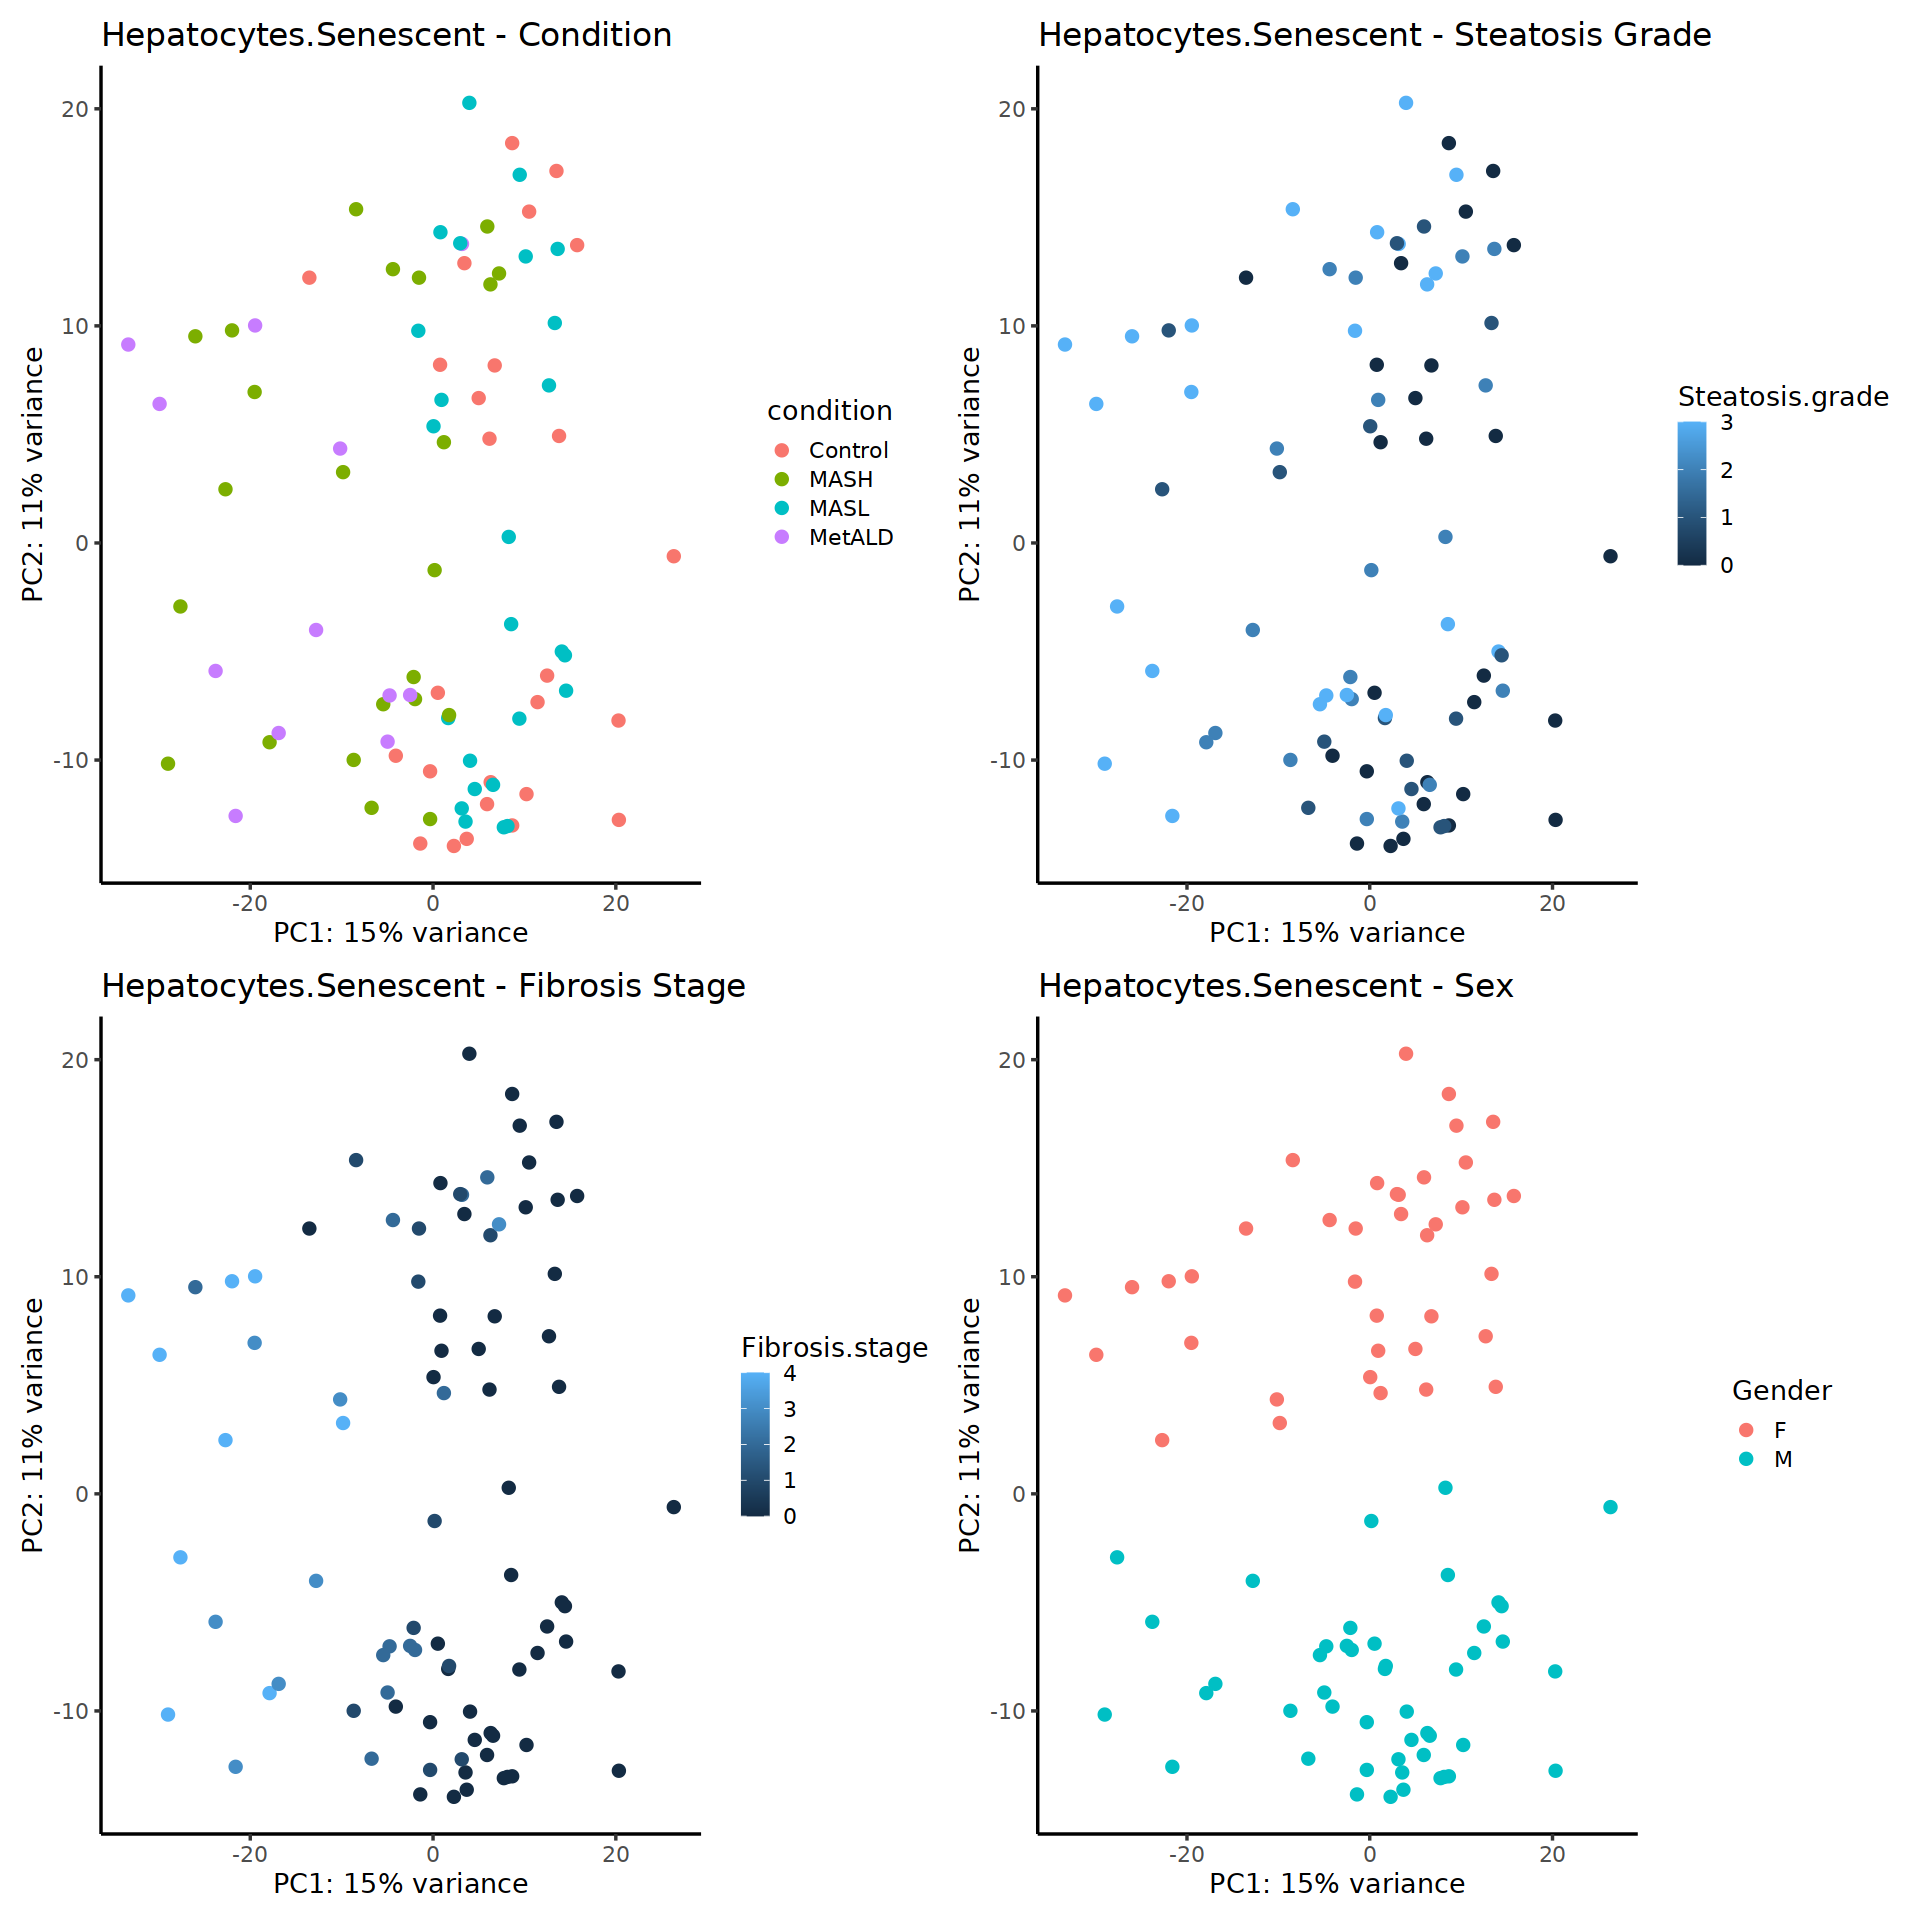

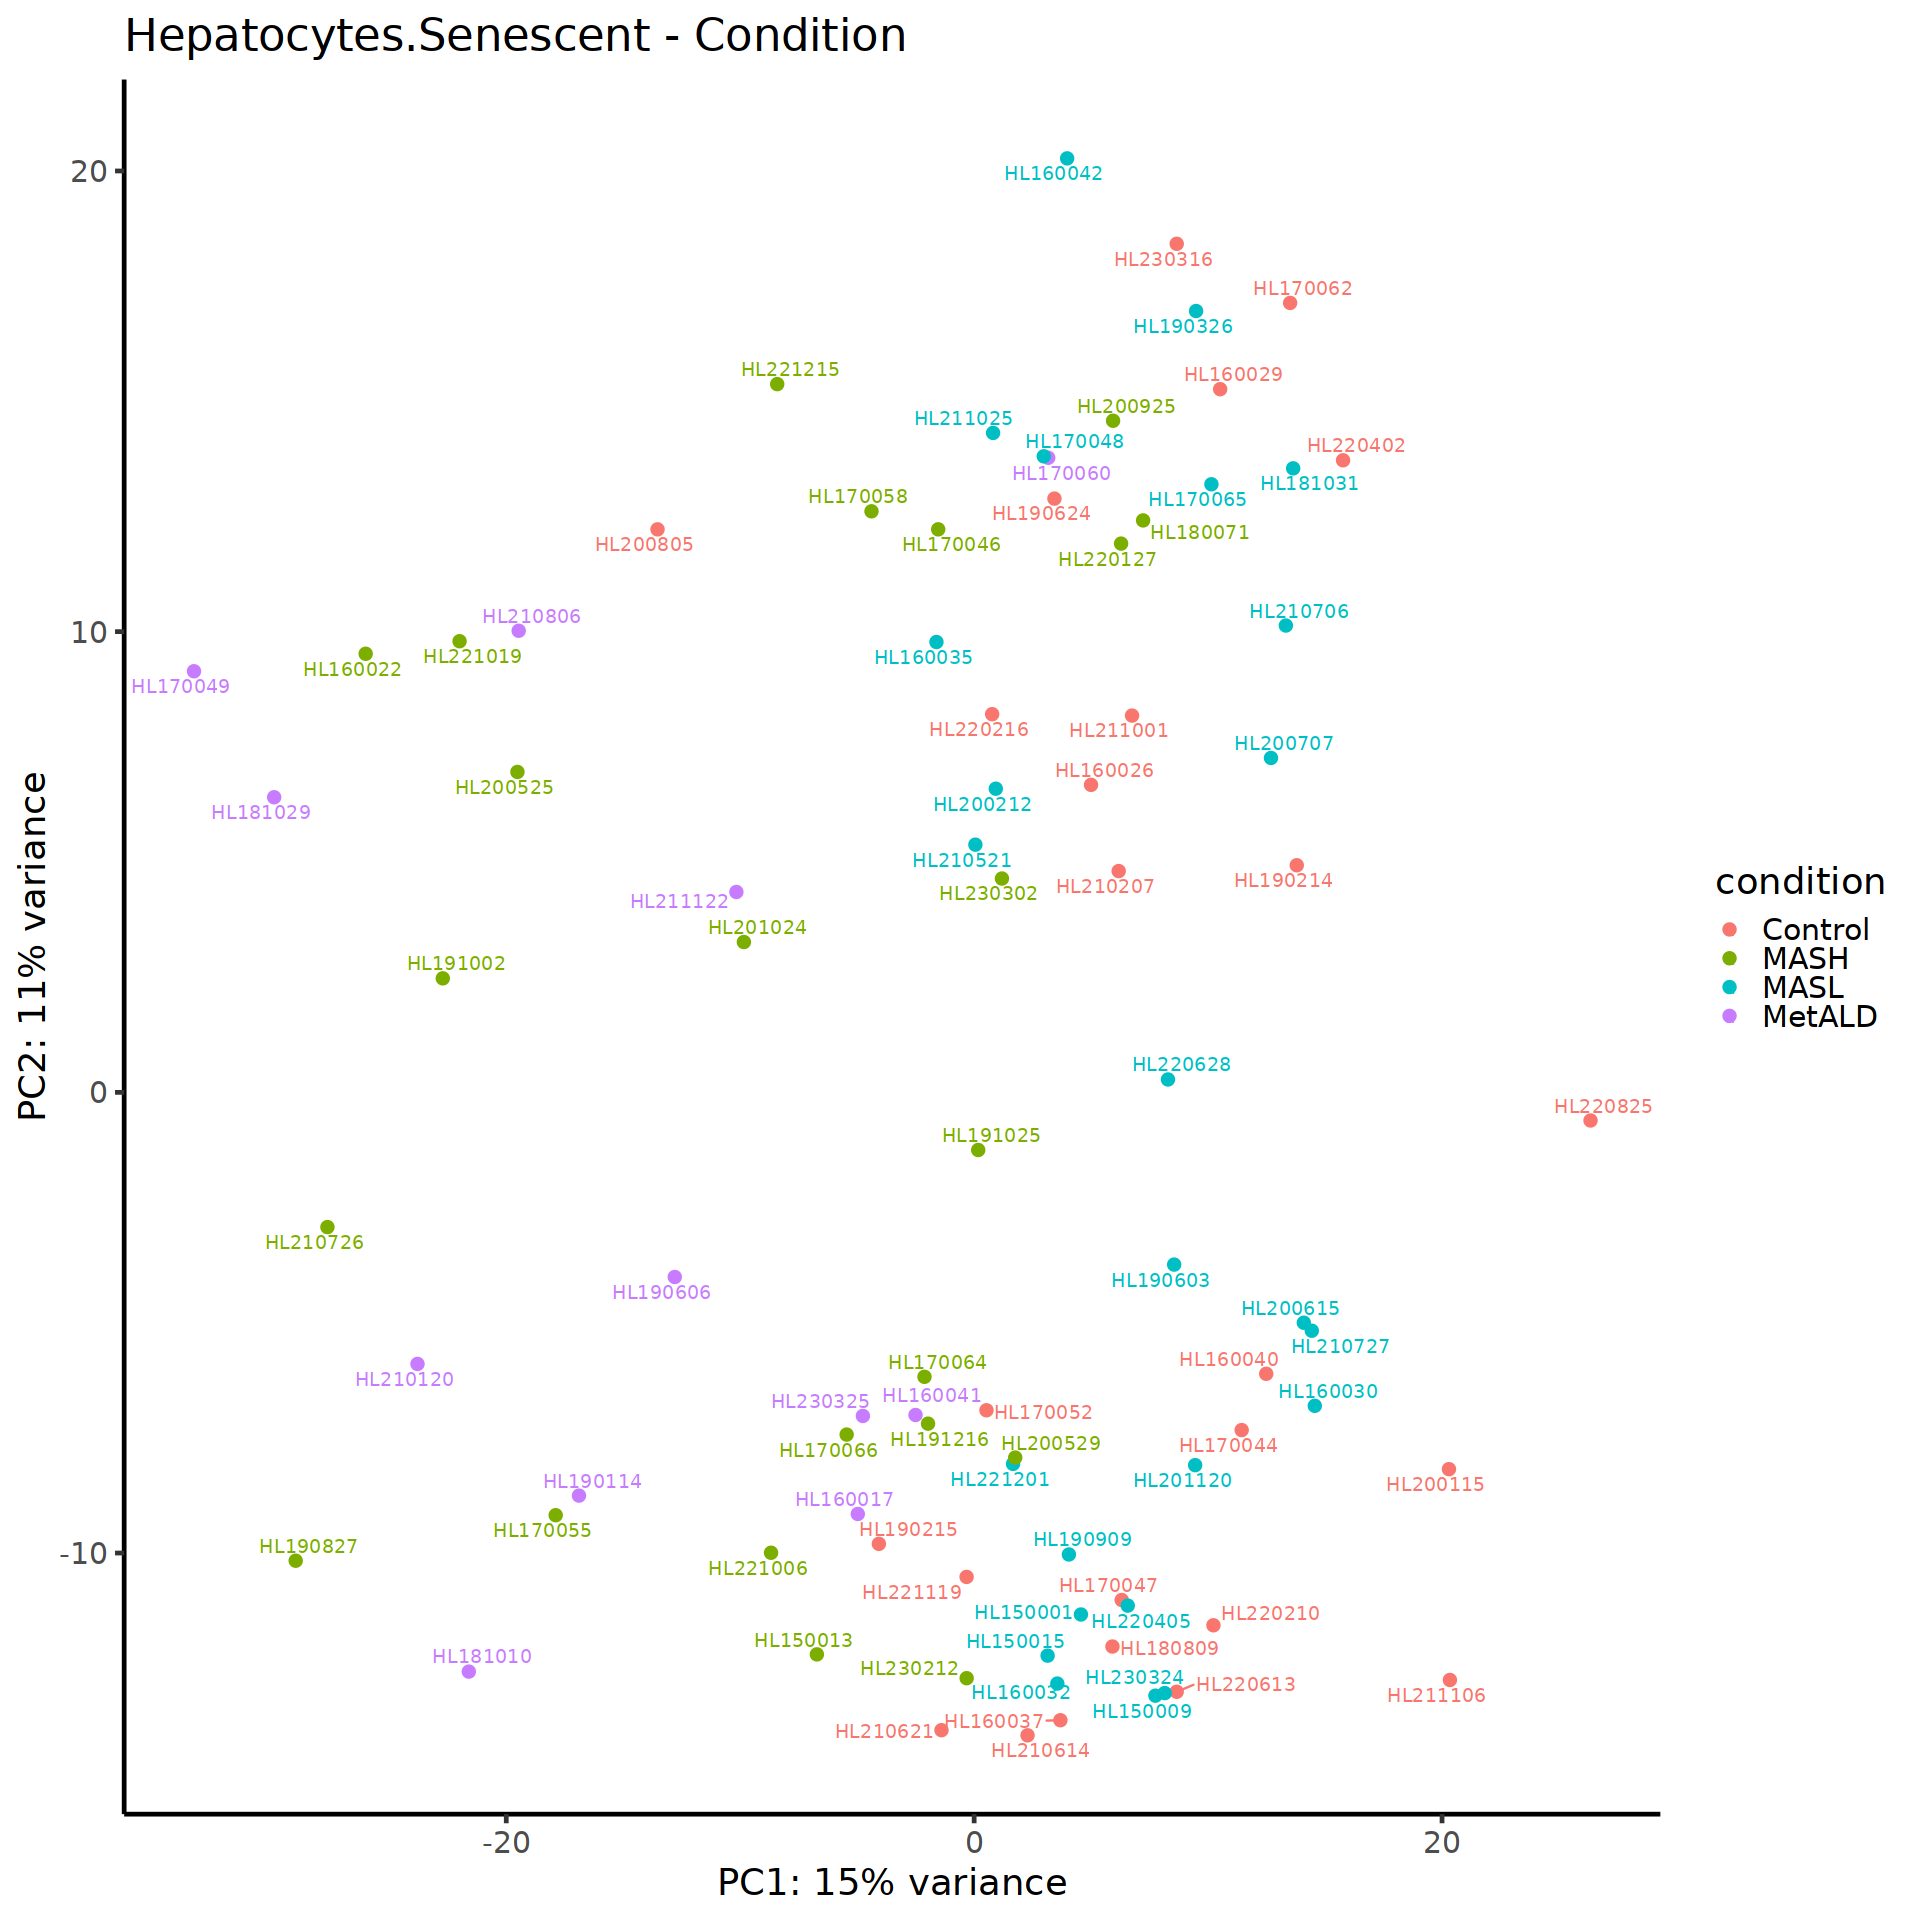

Warning message:
“ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone1"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


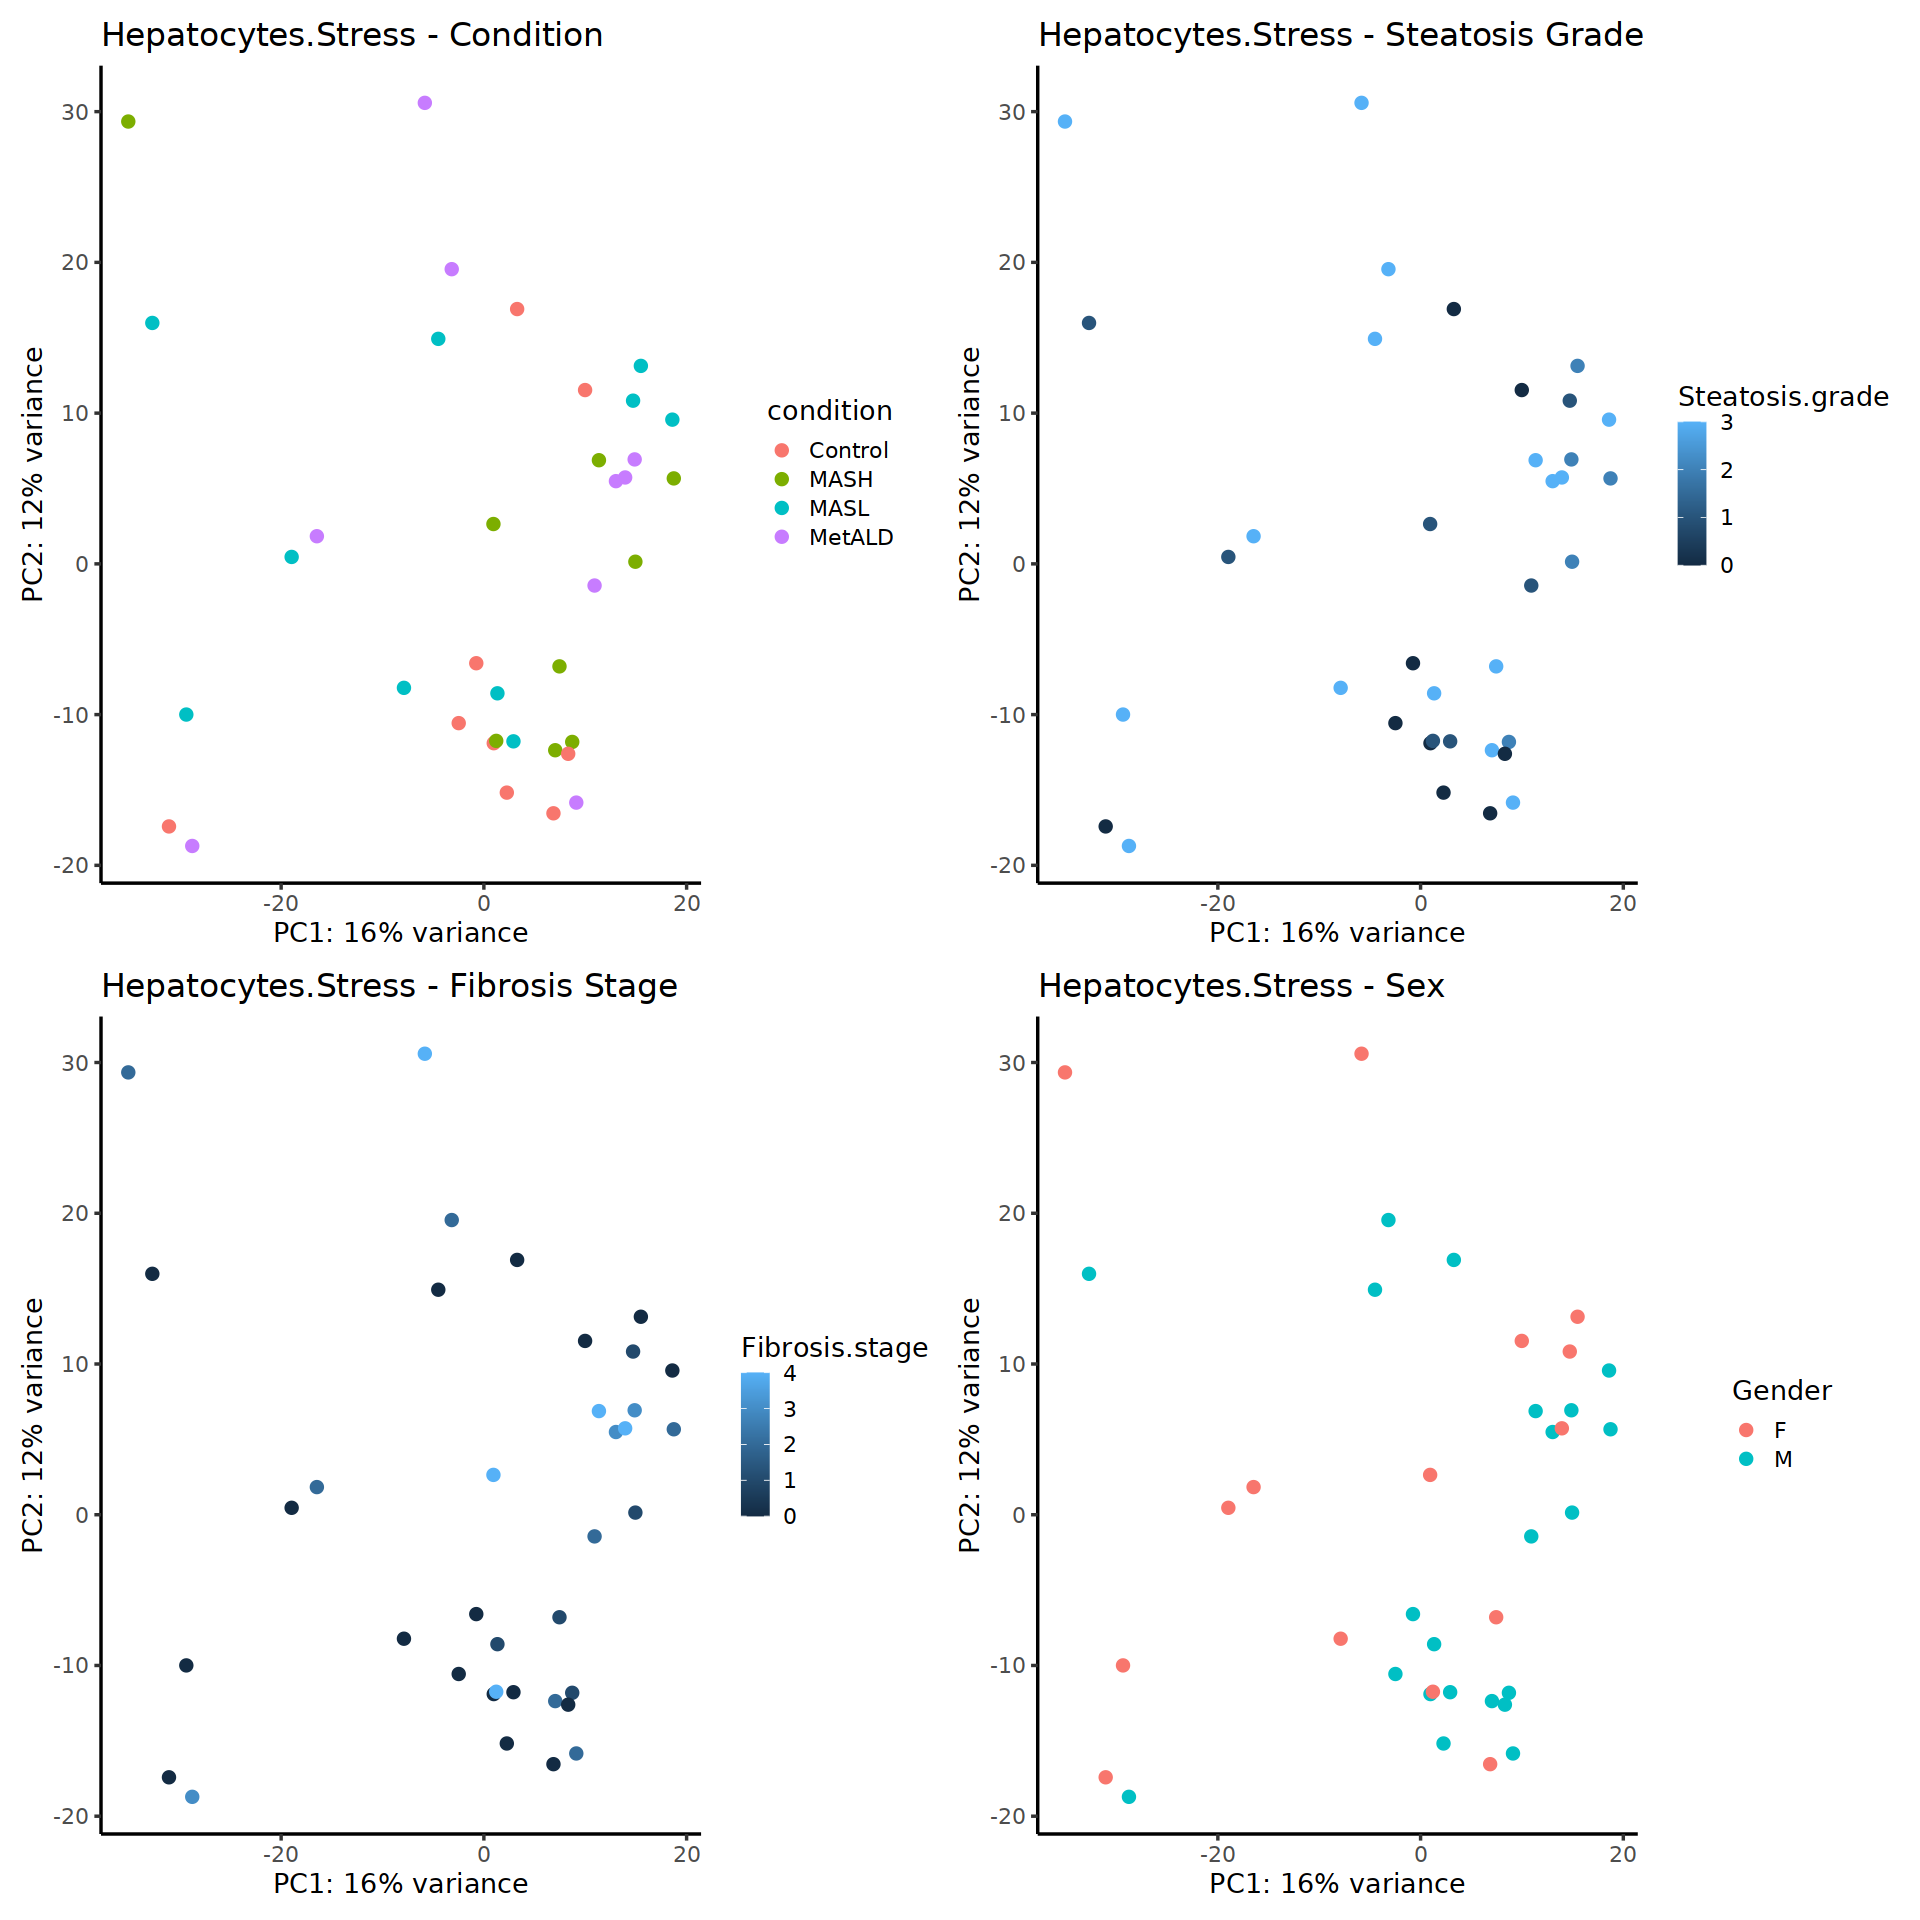

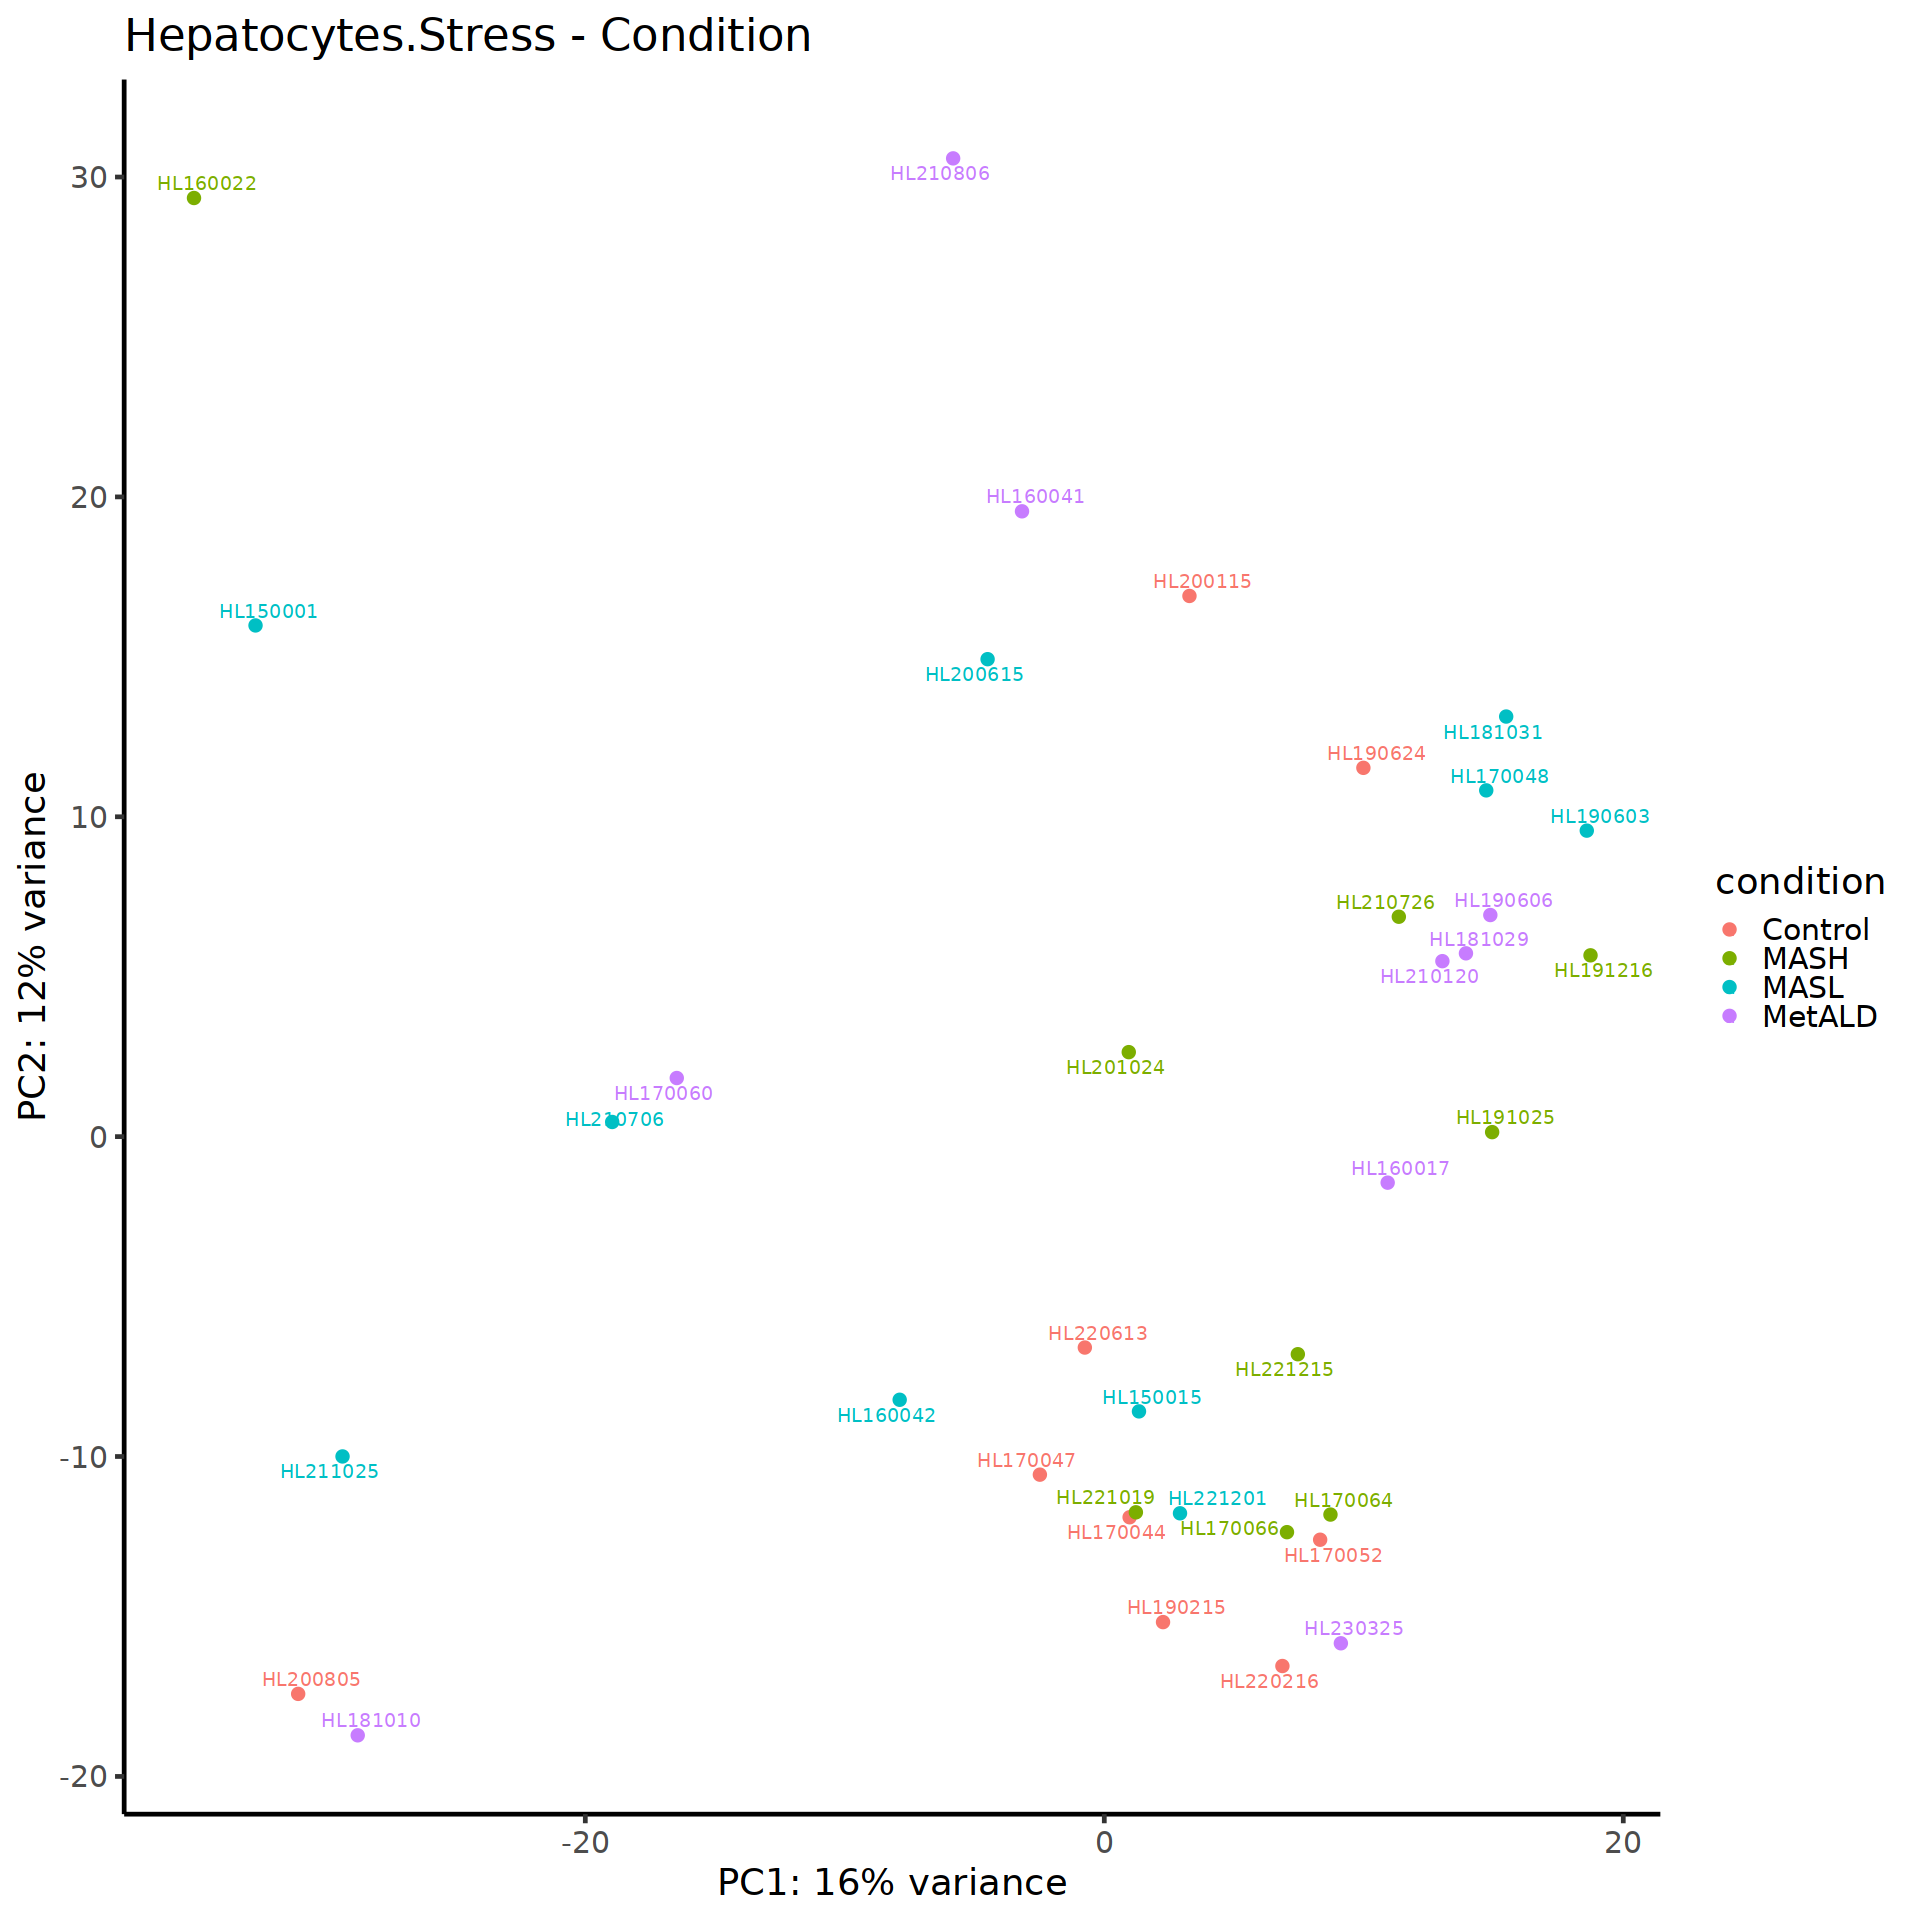

Warning message:
“ggrepel: 35 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone2"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


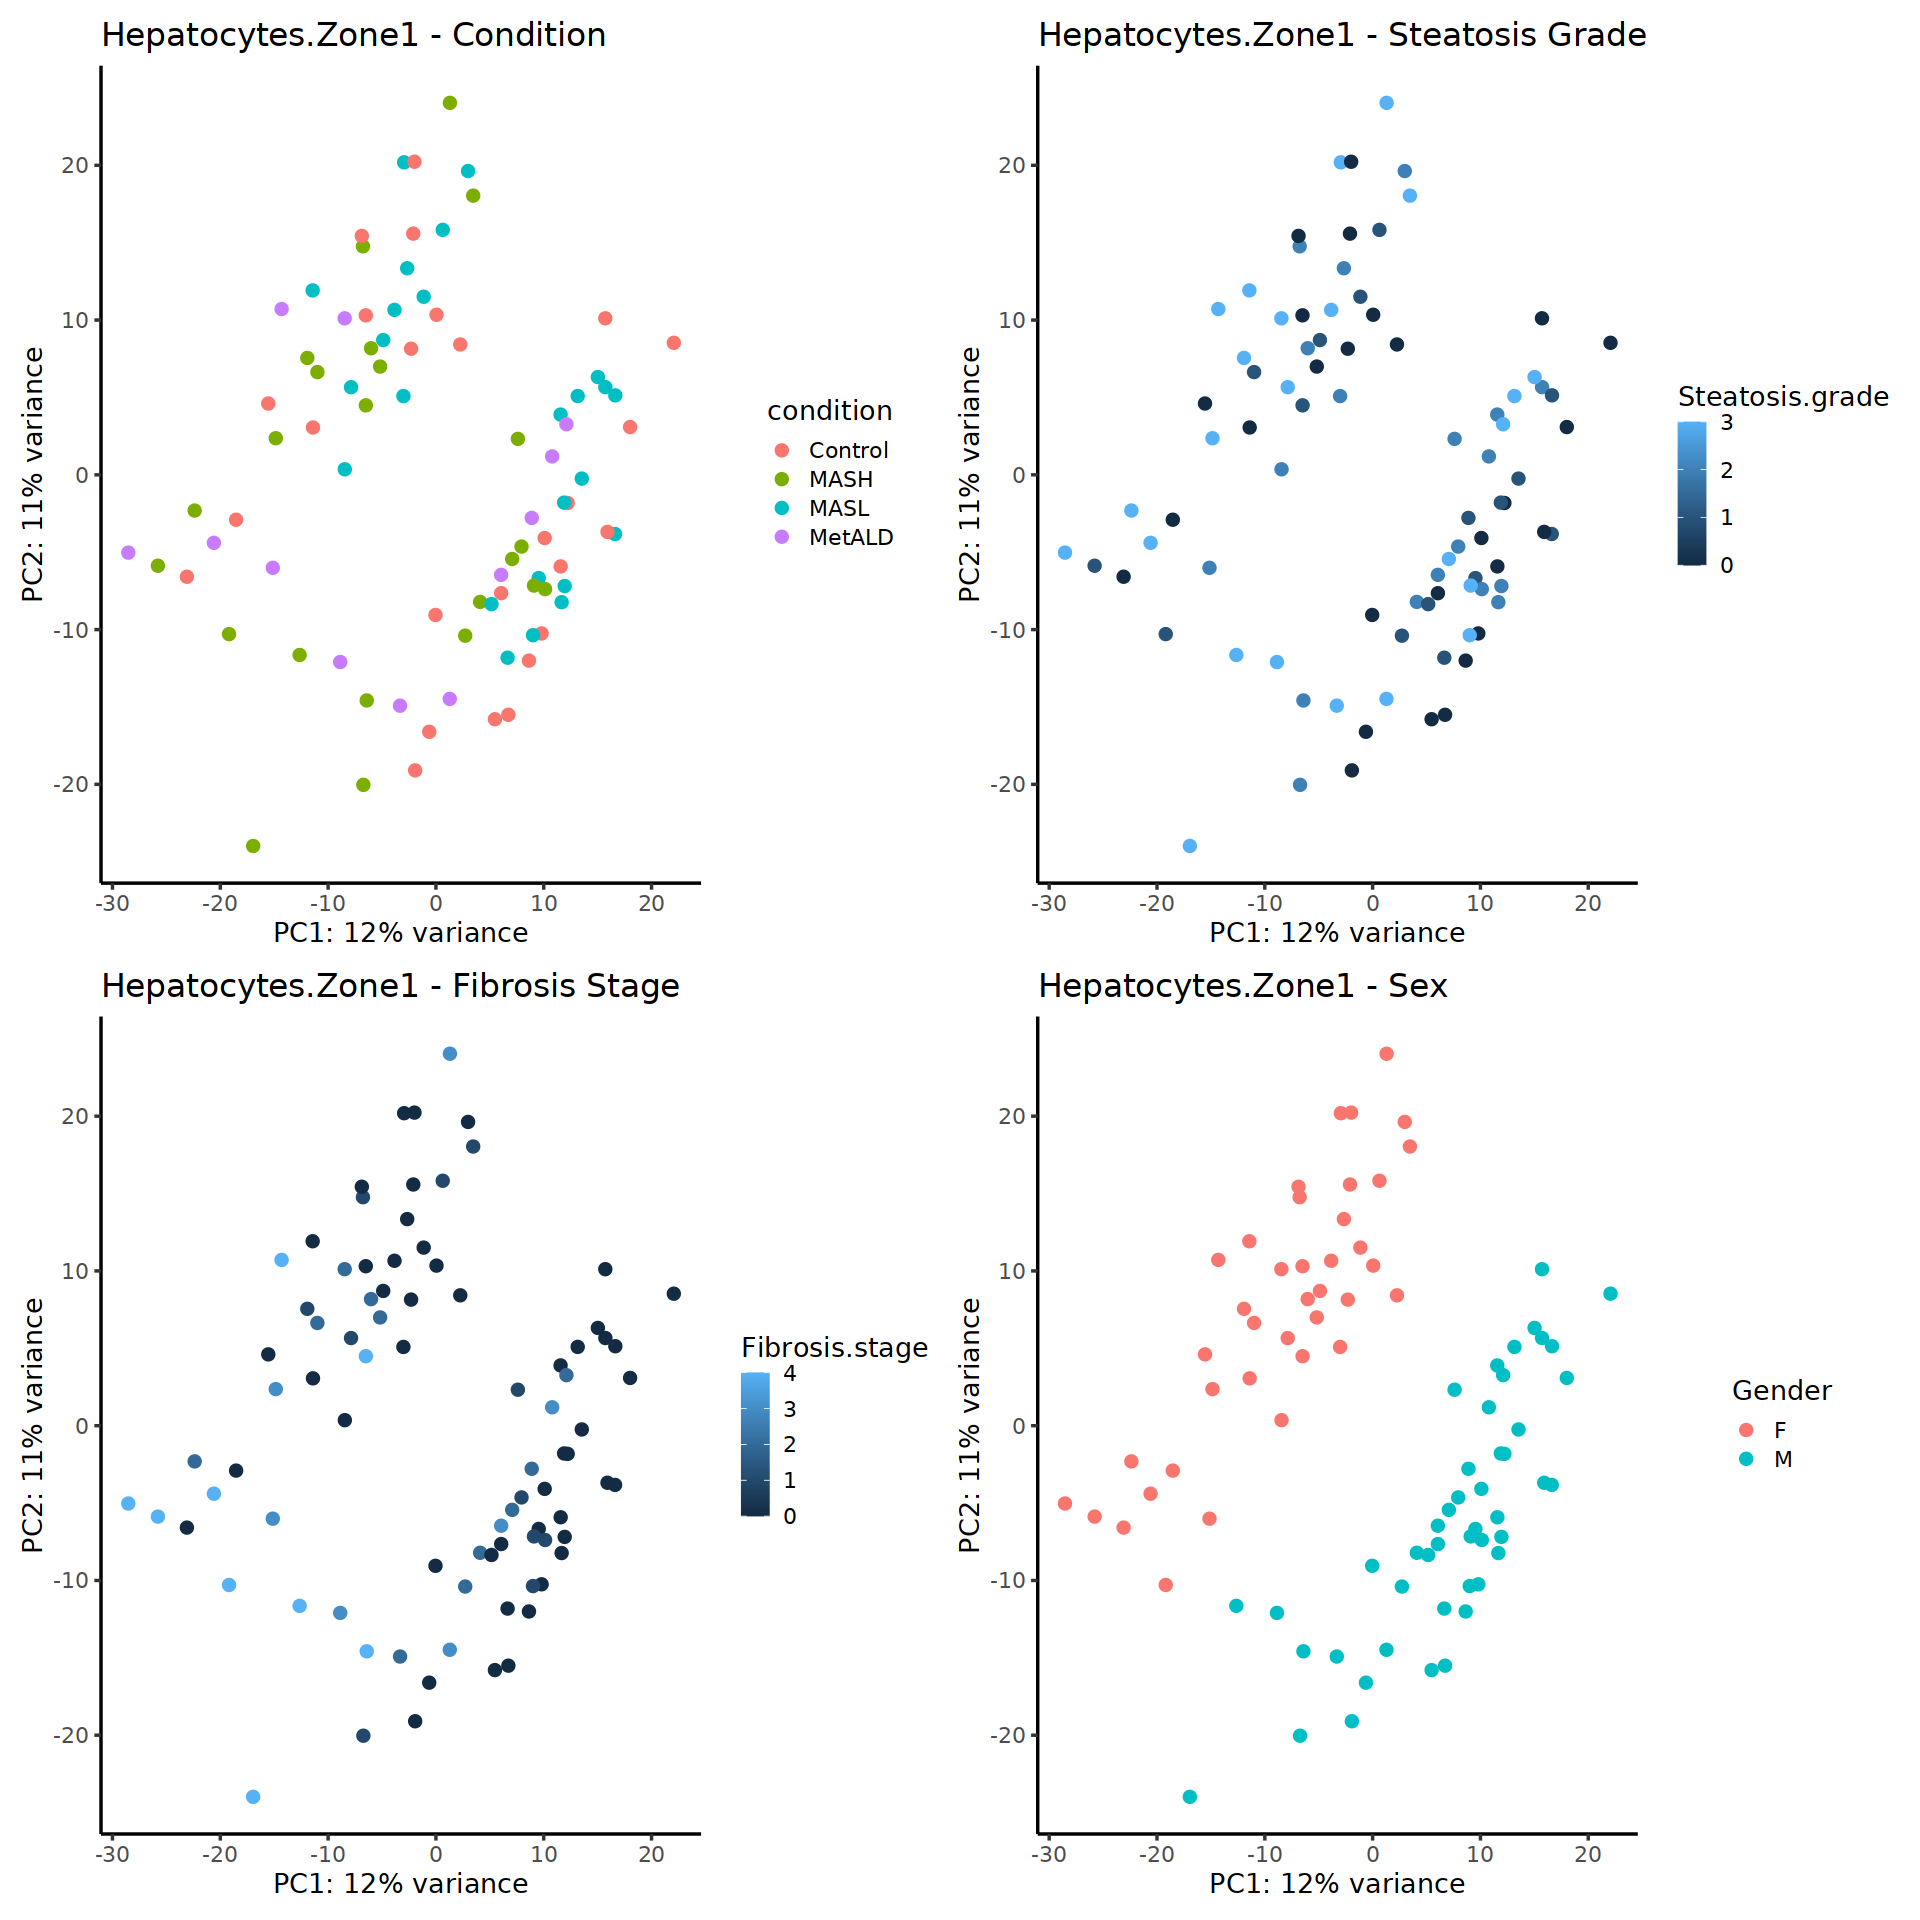

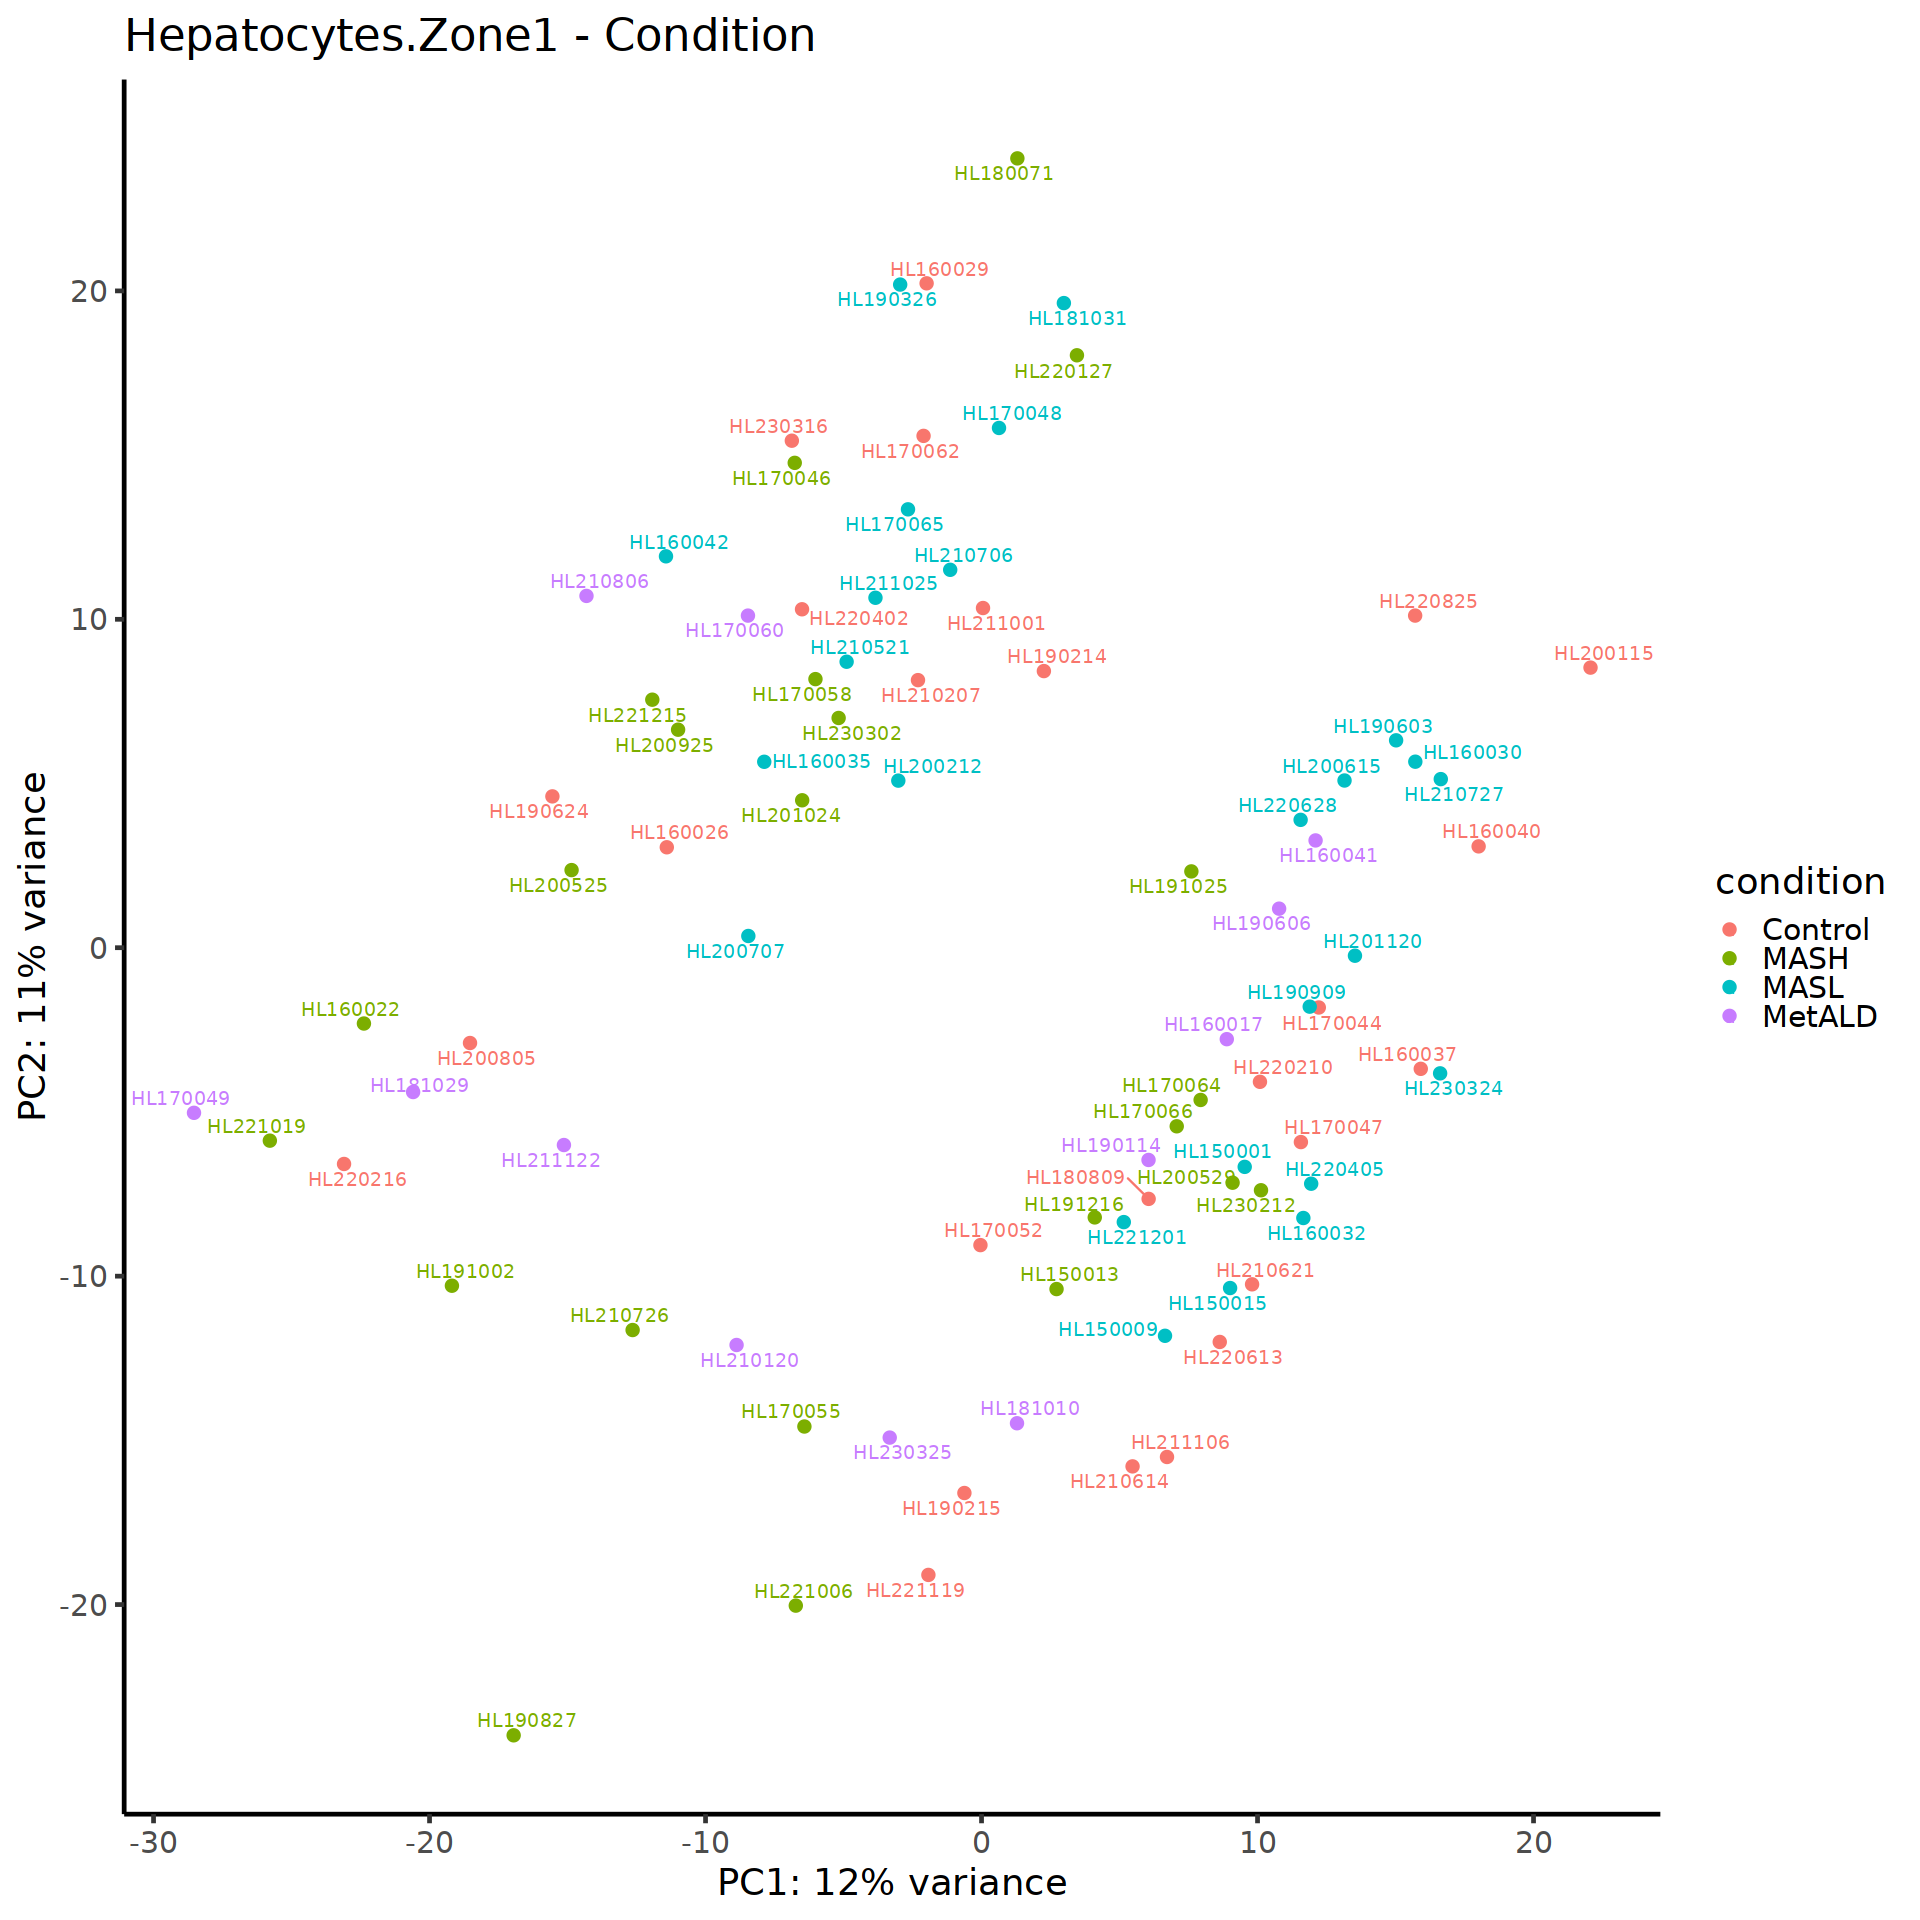

Warning message:
“ggrepel: 30 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone3"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


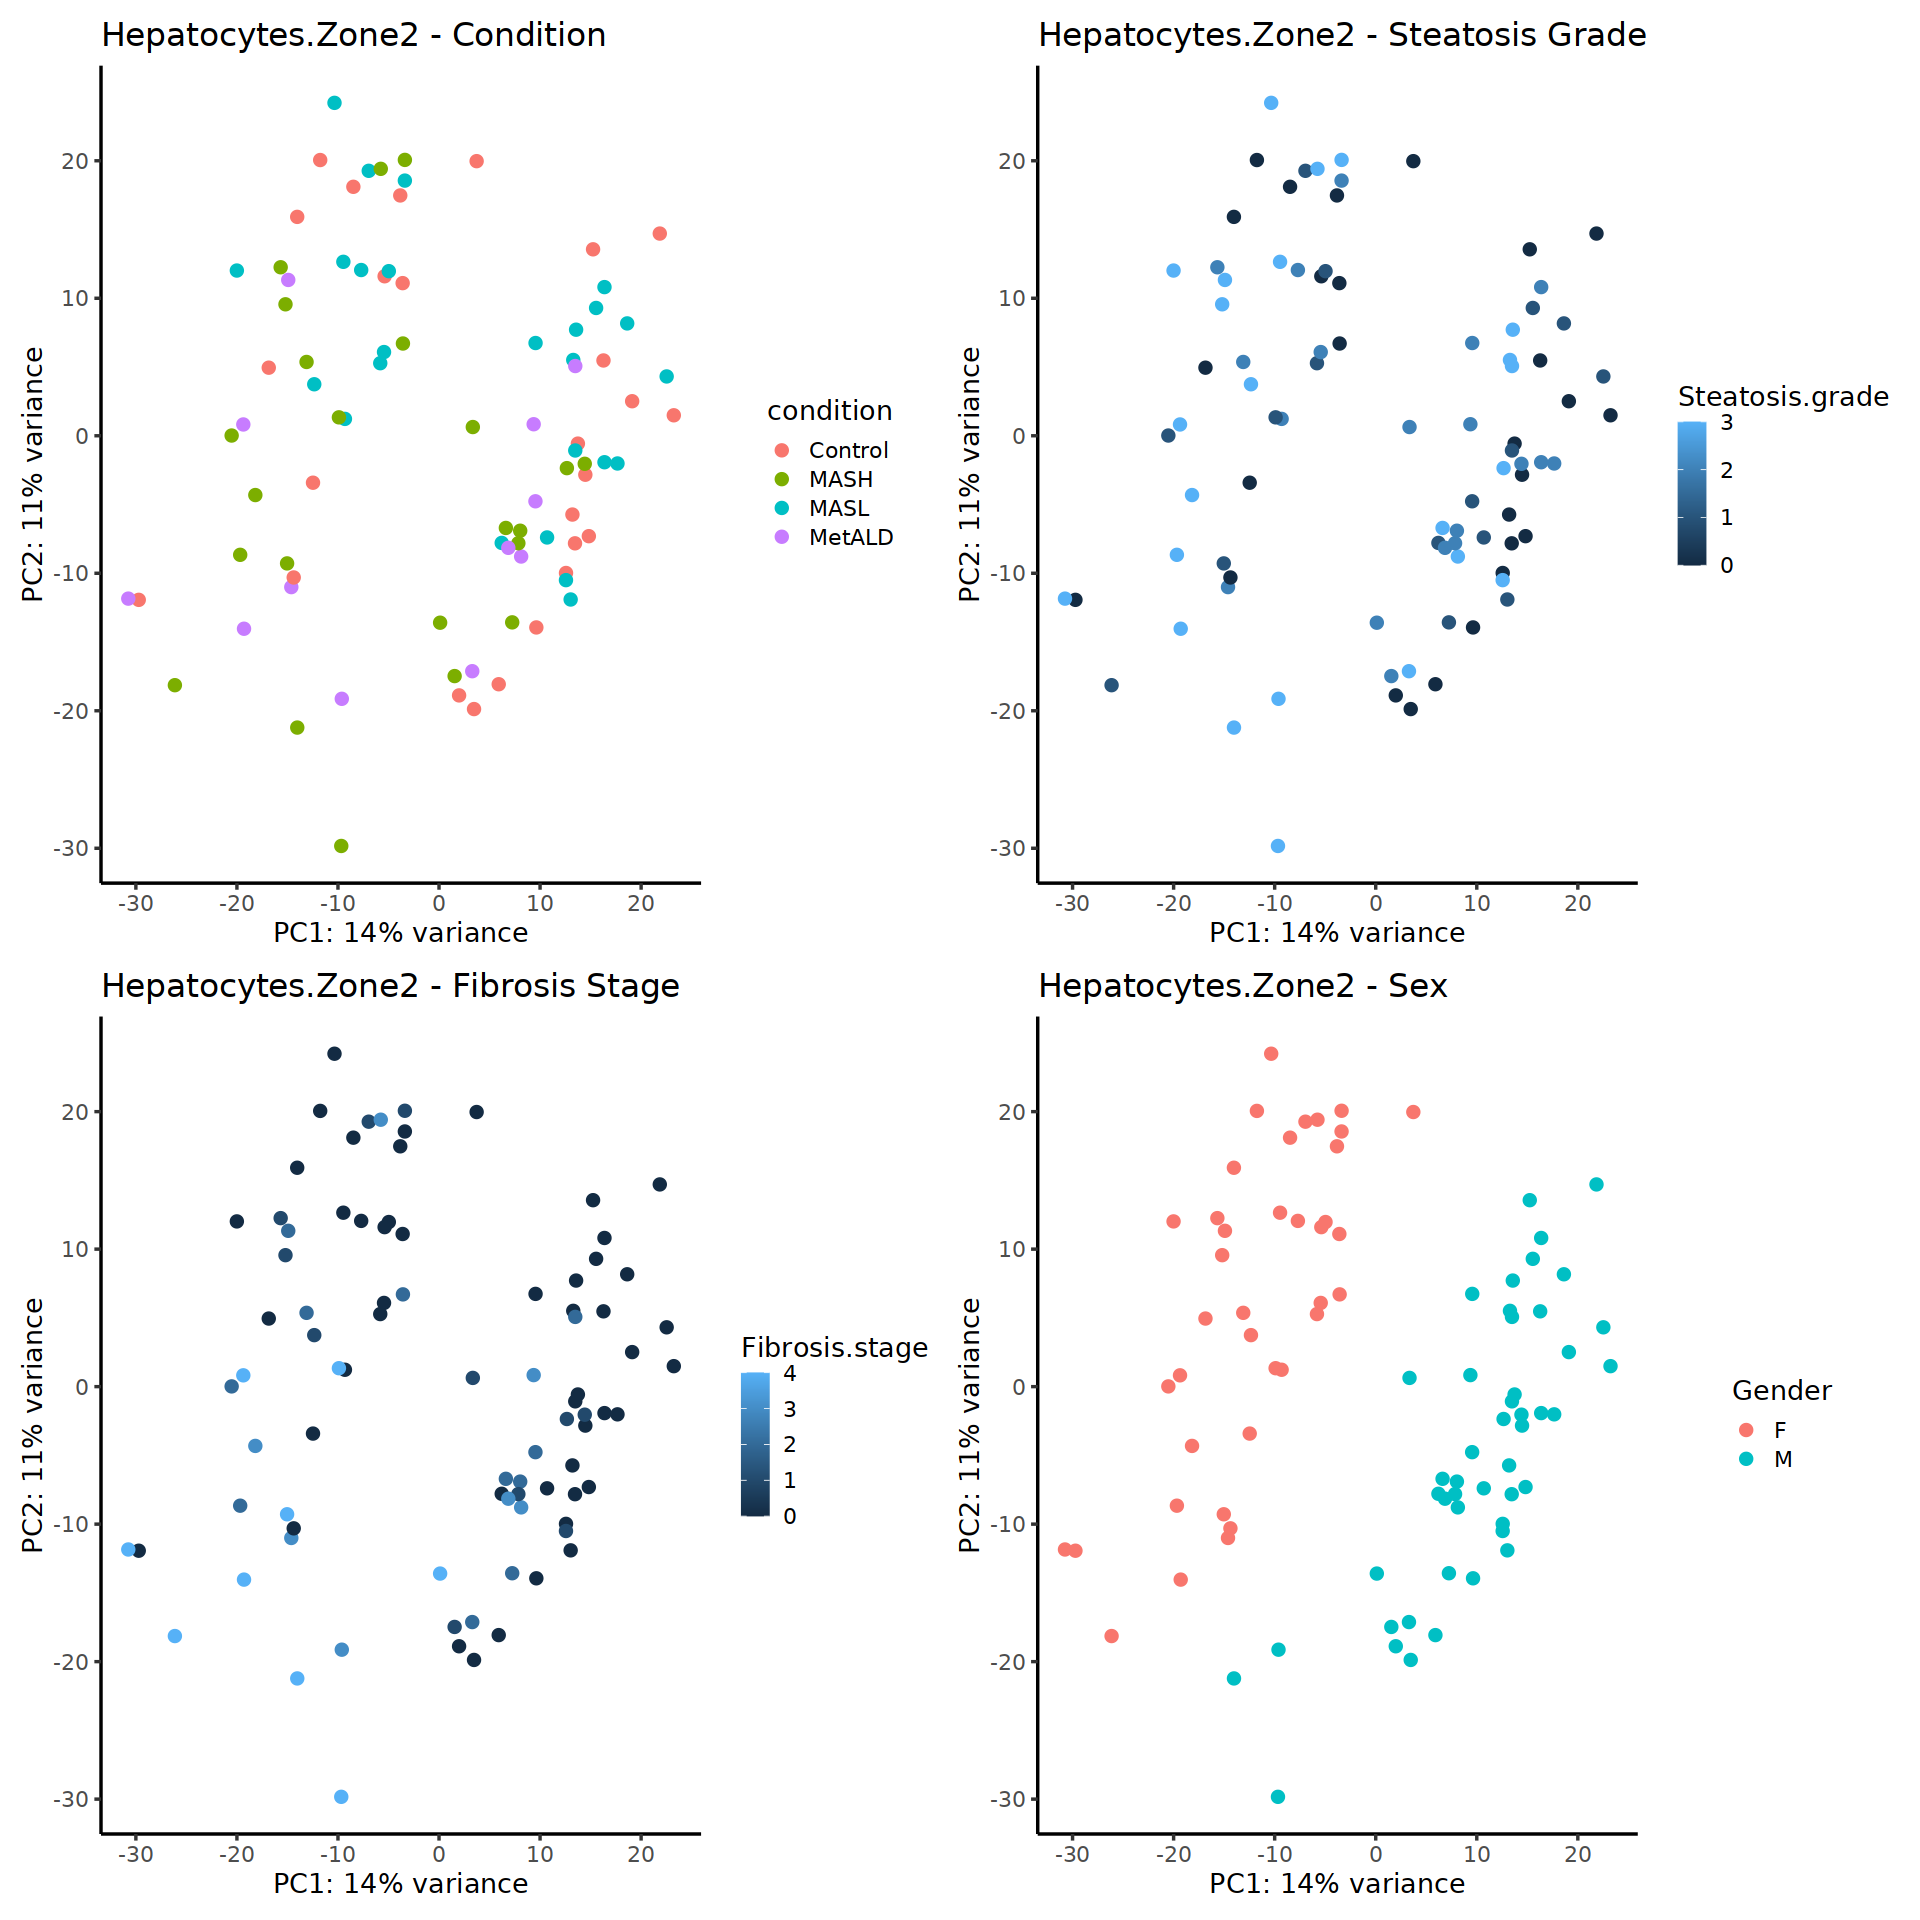

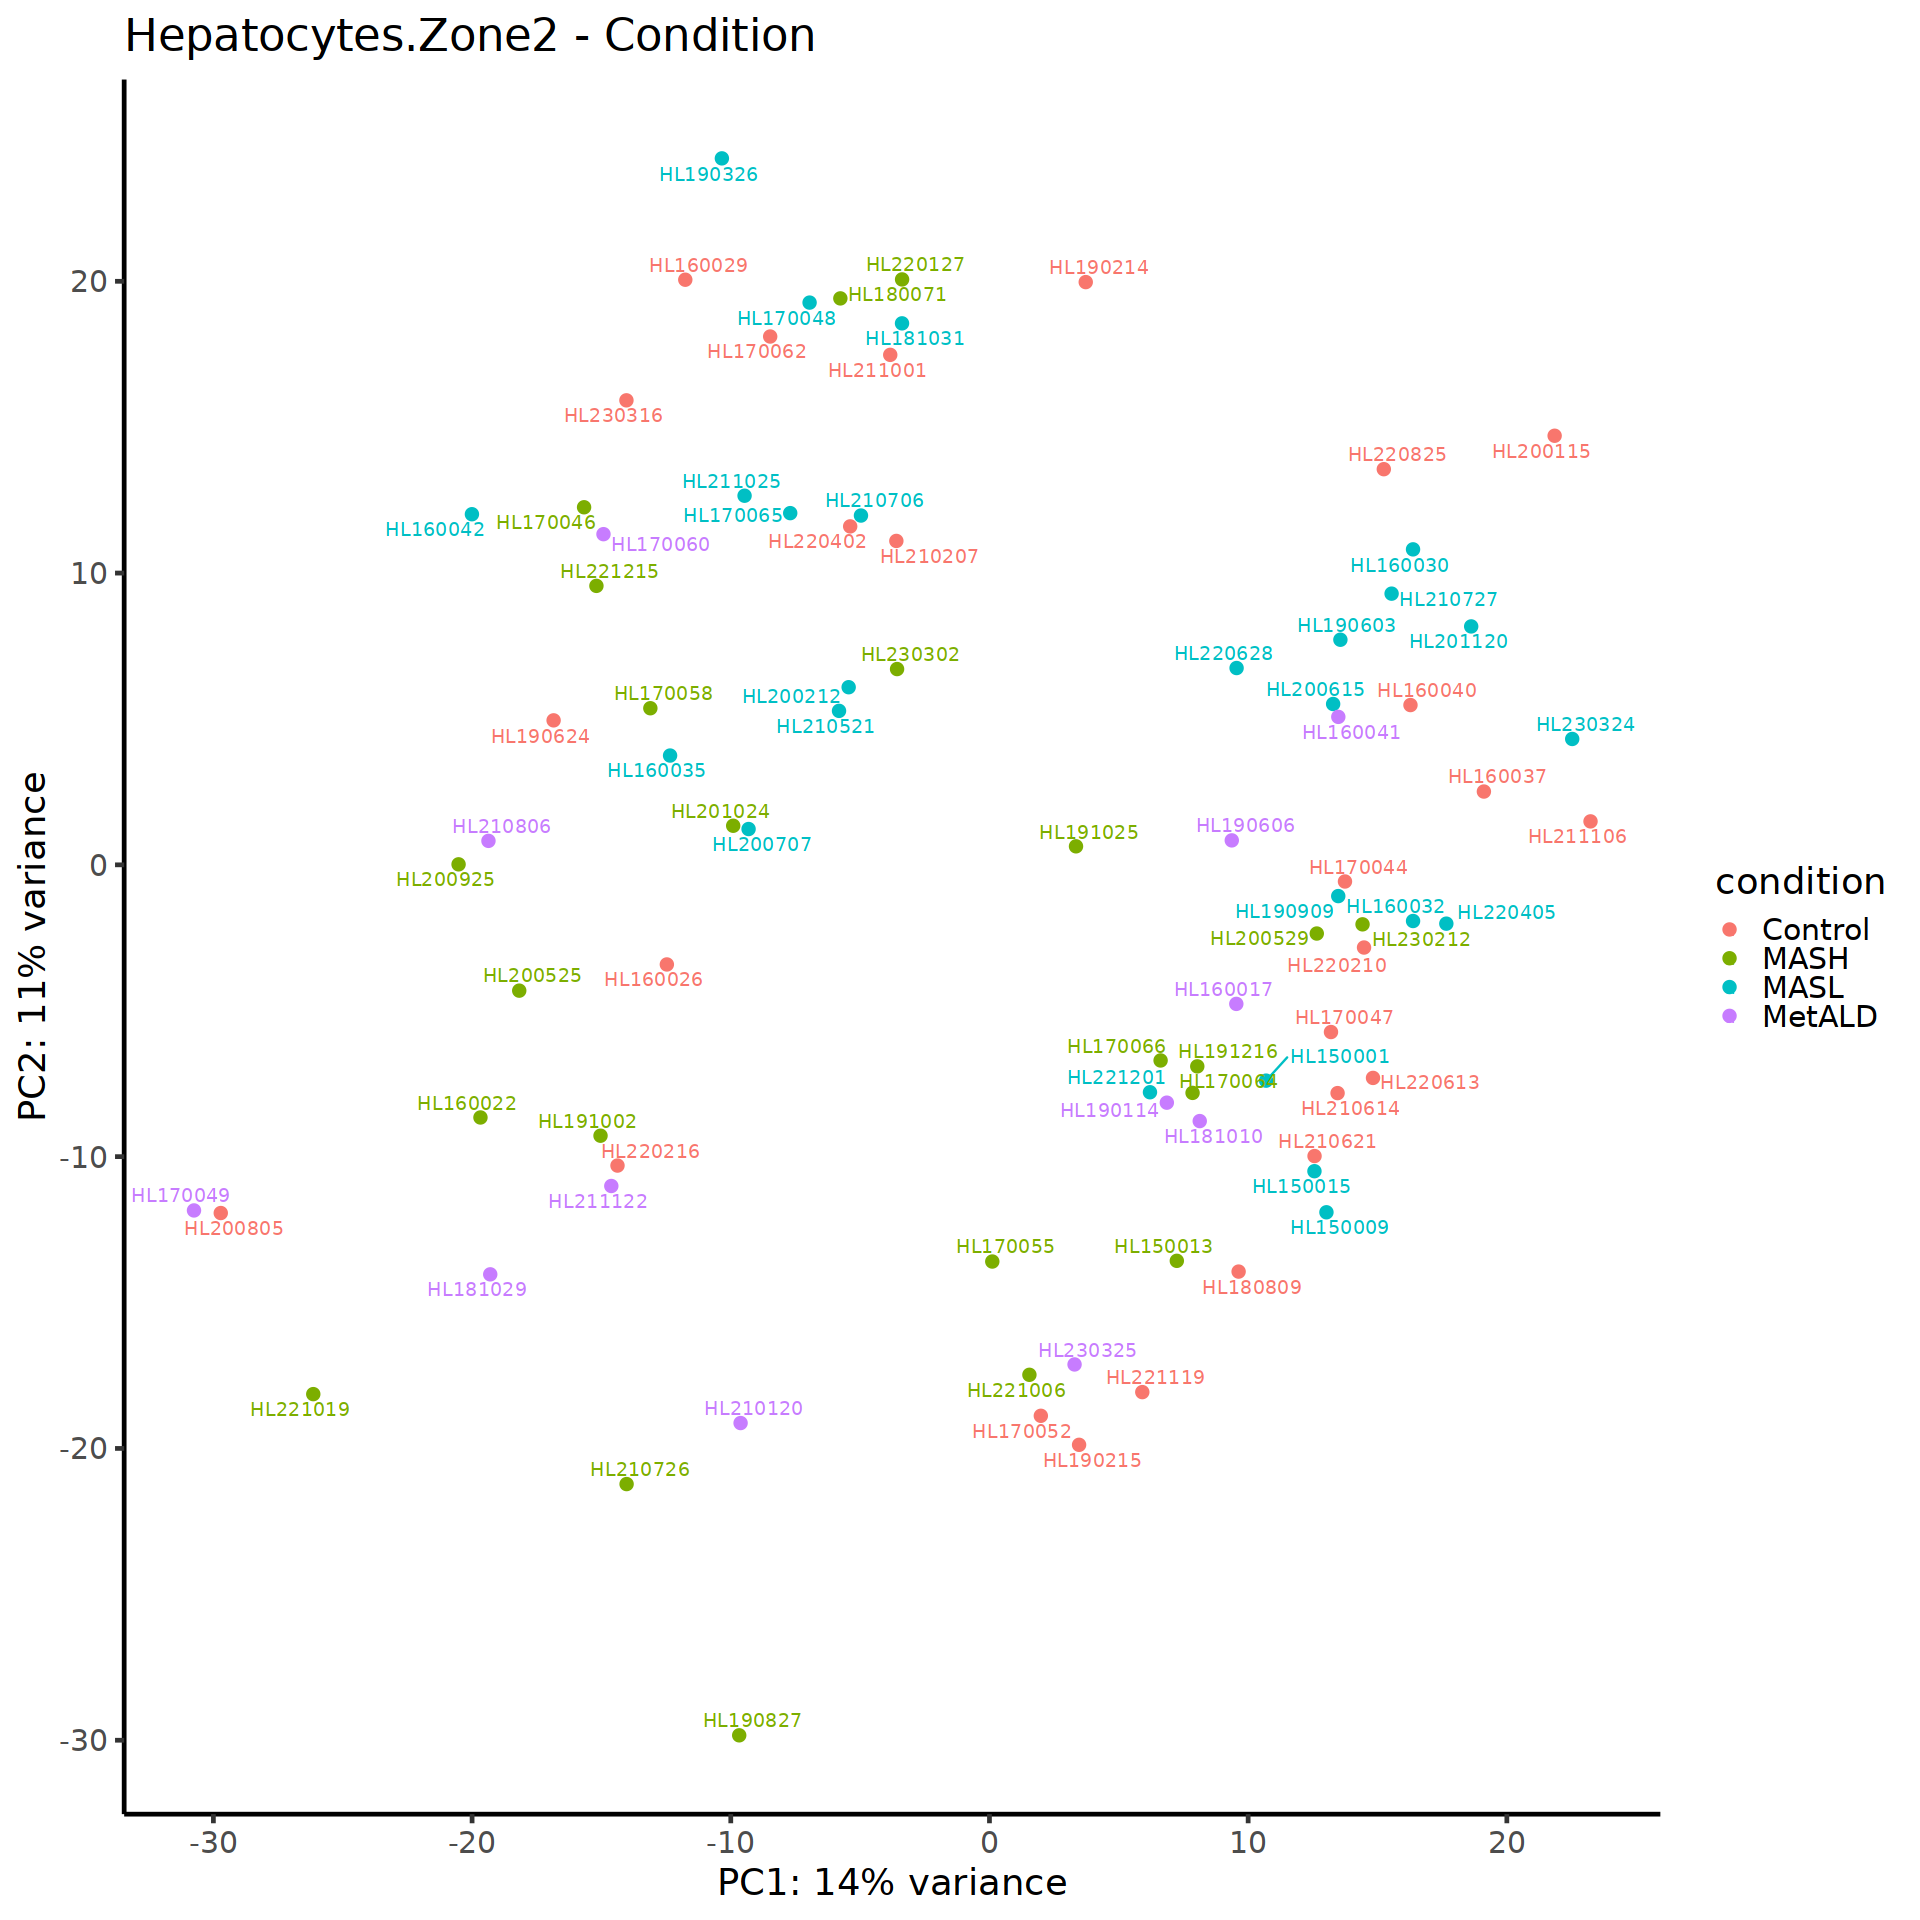

Warning message:
“ggrepel: 46 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


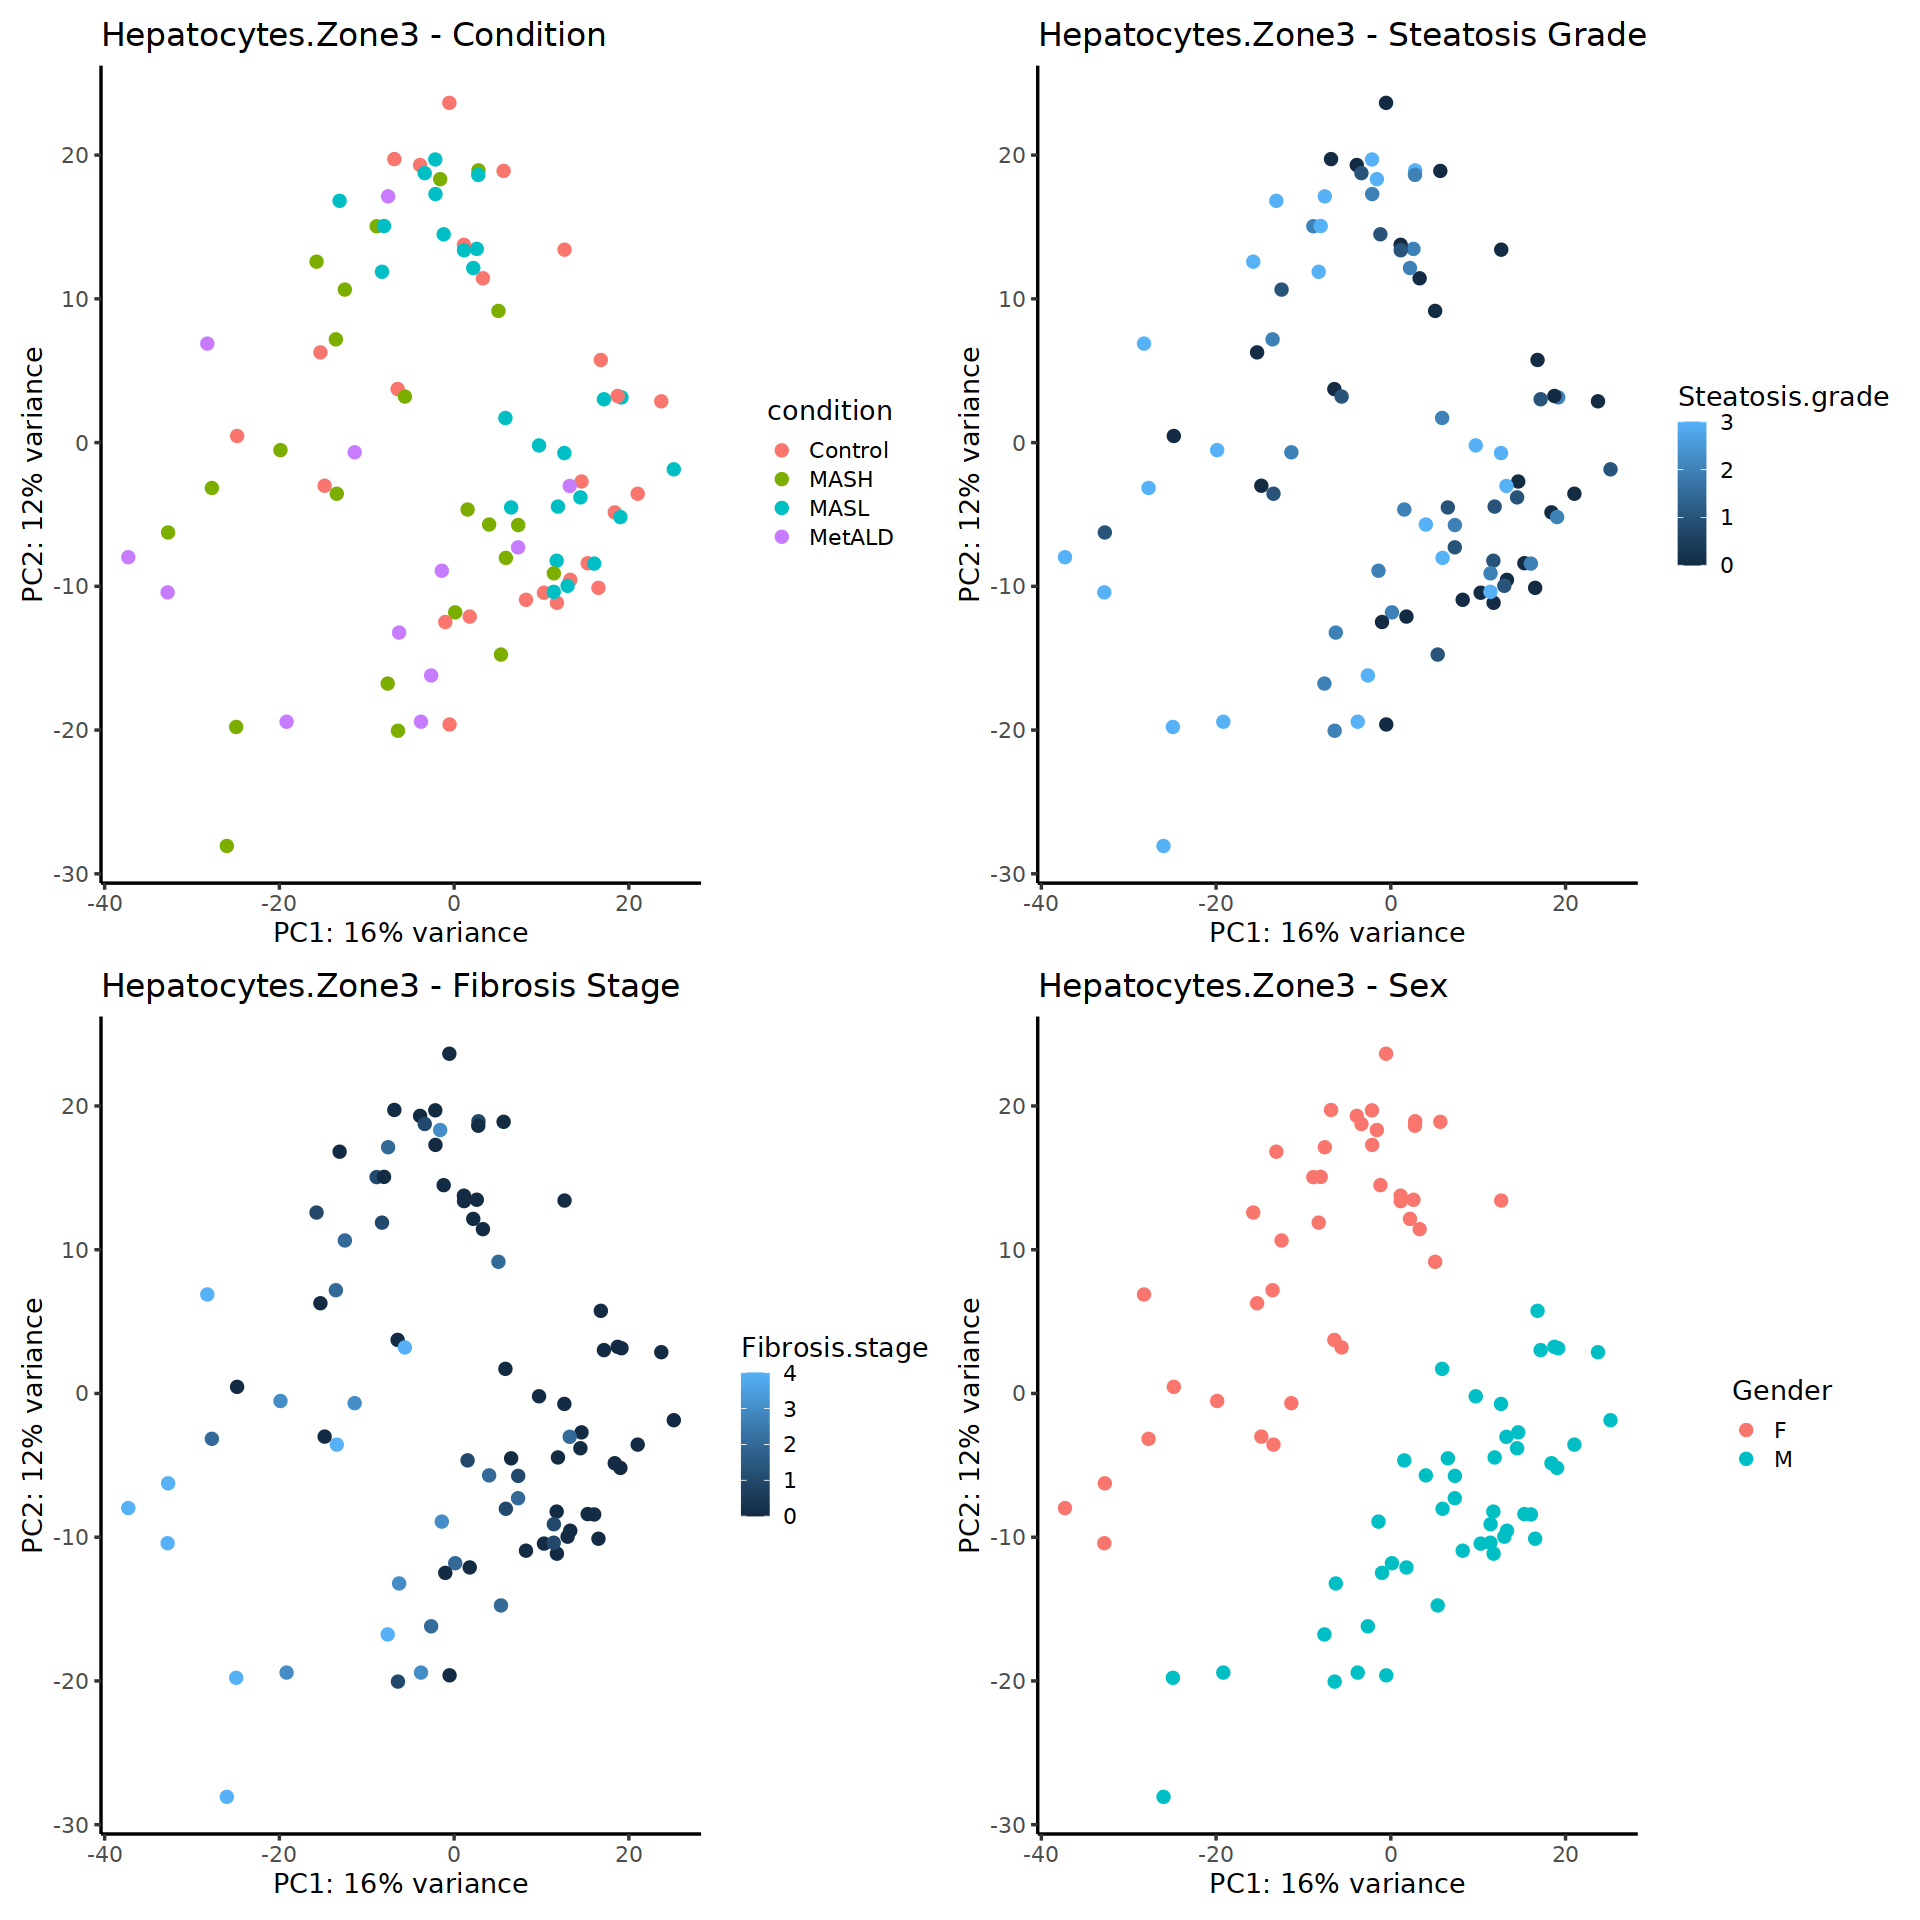

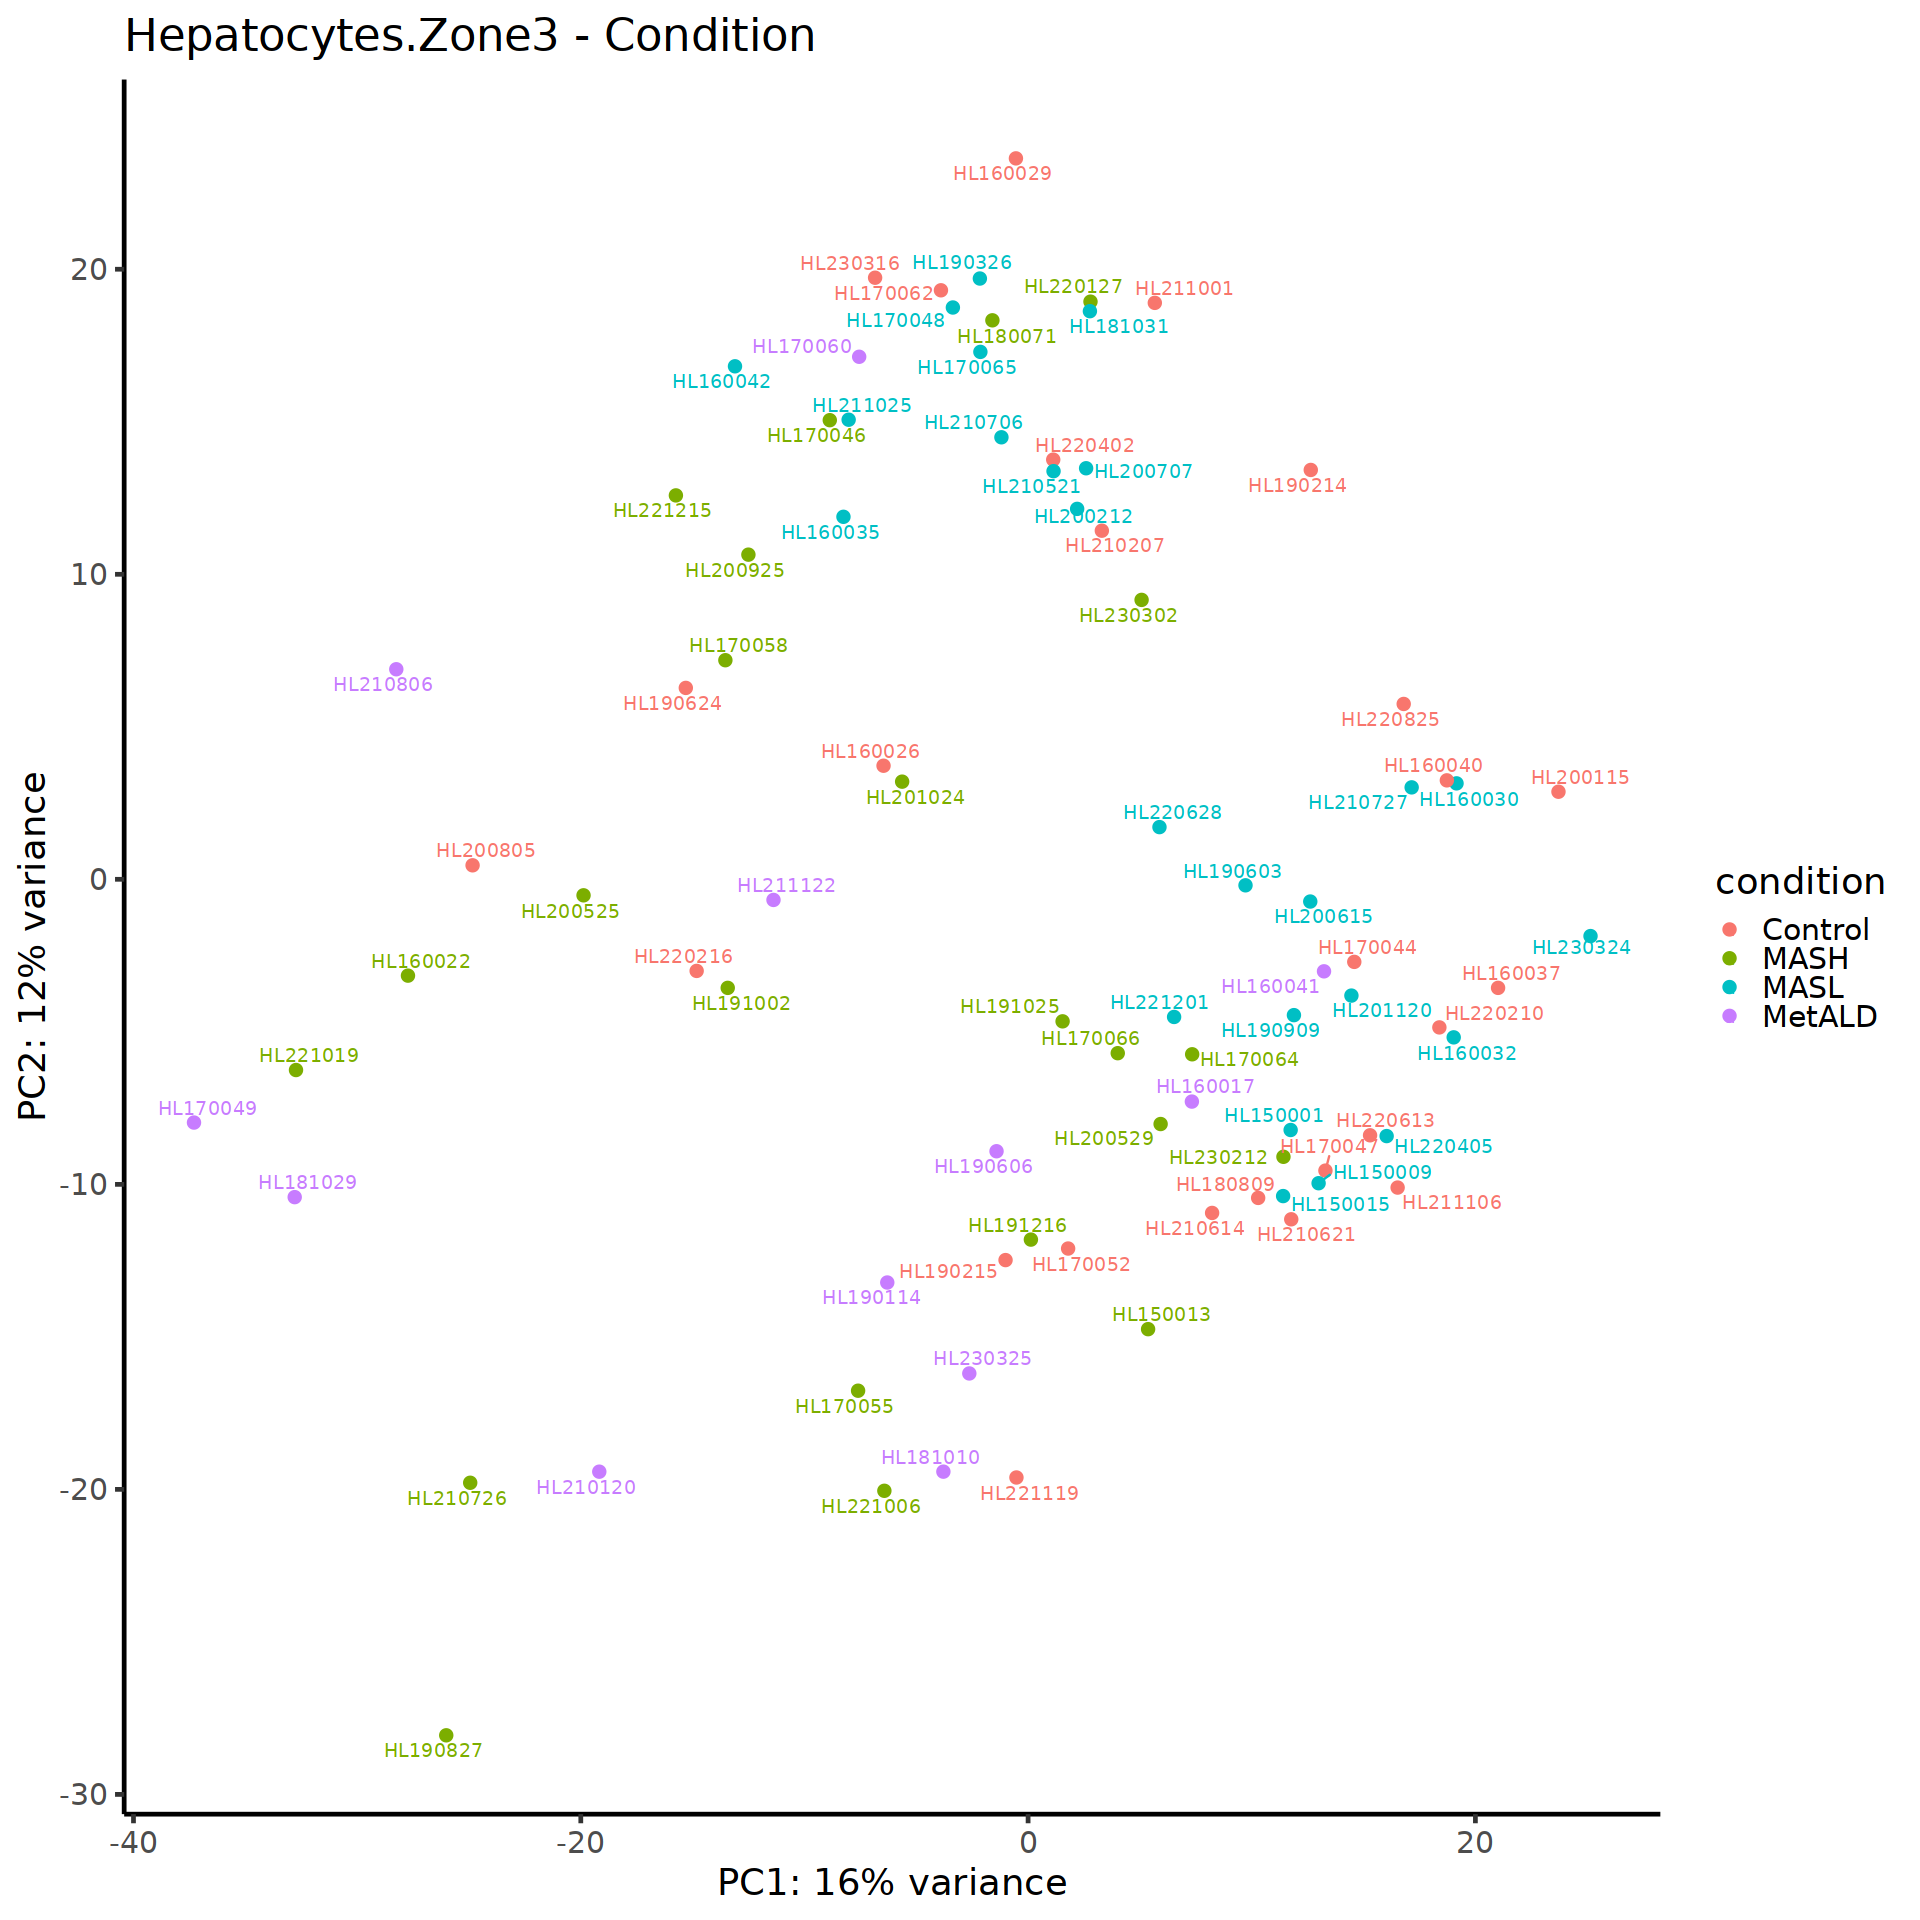

In [6]:
options(repr.plot.width=16, repr.plot.height=16)
pca_data <- list()

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Mast','Schwann')) {
        next
    }
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Filter for only samples with any counts in the cell type
    raw_counts = raw_counts[, (colSums(raw_counts != 0) > 0)]
    message("Donors detectected with celltype: ", ncol(raw_counts))
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    dds <- DESeqDataSetFromMatrix(countData = raw_counts,
                              colData = meta_cell,
                              design = ~ condition)
    vsd <- vst(dds, blind=FALSE)
    
    pcaData <- plotPCA(vsd, intgroup=c("condition"), returnData=TRUE)
    pca_data[[cell.use]] <- left_join(pcaData, select(meta_cell, -condition), join_by(name==donor_demux))
    gc()
    
    percentVar <- round(100 * attr(pca_data[[cell.use]], "percentVar"))

    p1 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=condition, label=name)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Condition')) + theme_classic(base_size=16)
        
    p2 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=Steatosis.grade)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Steatosis Grade')) + theme_classic(base_size=16)
        
    p3 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=Fibrosis.stage)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Fibrosis Stage')) + theme_classic(base_size=16)
        
    p4 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=Gender)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Sex')) + theme_classic(base_size=16)
    p6 <- p1 + p2 + p3 + p4
    print(p6)
    
    p5 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=condition, label=name)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Condition')) + theme_classic(base_size=22) + ggrepel::geom_text_repel(size=4)
    print(p5)
    
    write.table(pca_data[[cell.use]], paste0(outdir, cell.use, '_PCA.tsv'),
               sep='\t', col.names=T, row.names=T, quote=F)
}

# DESeq2 - Conditions status

In [1]:
meta = read.table("/nfs/lab/mkim/Liver_Multiome/downstream/01_DESEQ_RNA_Hepatocytes_Subtypes/RNA.meta.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,batch,disease_status,condition,Steatosis.grade,⋯,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,⋯,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,HL150001,392,1,541,5047,2779,thirdPR,Disease,MASL,1,⋯,0,0,0,0,1,M,47,27.1,-0.6385847,-0.01553551
2,HL150009,25,0,124,1655,513,fourthPR,Disease,MASL,1,⋯,0,0,0,0,1,M,37,29.4,-0.3346869,-0.75778750


[1] "donor_demux"           "Hepatocytes.Senescent" "Hepatocytes.Stress"   
 [4] "Hepatocytes.Zone1"     "Hepatocytes.Zone2"     "Hepatocytes.Zone3"    
 [7] "batch"                 "disease_status"        "condition"            
[10] "Steatosis.grade"       "Fibrosis.stage"        "Fat.distribution"     
[13] "Lobular.inflammation"  "Ballooning"            "Portal.inflammation"  
[16] "Hepatocyte.necrosis"   "MASH.CRN.score..X.8"   "Gender"               
[19] "Age"                   "BMI"                   "BMI.scaled"           
[22] "Age.scaled"

In [8]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/mkim/Liver_Multiome/downstream/count.matrices/RNA/'
#Create outdir for results
outdir <- '/nfs/lab/mkim/Liver_Multiome/downstream/01_DESEQ_RNA_Hepatocytes_Subtypes/'
# dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_perdonor.RNA.counts.tsv')
#Cut off file suffices to get celltype names
cells <- gsub('_perdonor.RNA.counts.tsv','', files) 

In [9]:
files  <- grep("^Hepatocytes", files, value=T)
files
cells <- grep("^Hepatocytes", cells, value=T)
cells

[1] "Hepatocytes.Senescent_perdonor.RNA.counts.tsv"
[2] "Hepatocytes.Stress_perdonor.RNA.counts.tsv"   
[3] "Hepatocytes.Zone1_perdonor.RNA.counts.tsv"    
[4] "Hepatocytes.Zone2_perdonor.RNA.counts.tsv"    
[5] "Hepatocytes.Zone3_perdonor.RNA.counts.tsv"

[1] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[4] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [10]:
# List your contrasts  
conditions.1 = c("MASL", "MASH", "MetALD") # disease
conditions.2 = c("Control", "Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [11]:
deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Mast.','Schwann.')) {
        next
    }
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Filter for only samples with any counts in the cell type
    raw_counts = raw_counts[, (colSums(raw_counts != 0) > 0)]
    message("Donors detectected with celltype: ", ncol(raw_counts))
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.1) %>% 
                               pull(donor)
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                          colData = meta_cell.use, 
                                          design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: Hepatocytes.Senescent"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - MASH_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 42 unlabeled data points (too many overlaps). Consider increasing m

[1] "Analyzing: Hepatocytes.Stress"


Donors detectected with celltype: 37

subsetting metadata accordingly - Check that value is equal to above: 37

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - MASH_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitTy

[1] "Analyzing: Hepatocytes.Zone1"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 10 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
  - MASH_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join

[1] "Analyzing: Hepatocytes.Zone2"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - MASH_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 65 unlabeled data points (too many overlaps). Consider increasing m

[1] "Analyzing: Hepatocytes.Zone3"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - MASH_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 70 unlabeled data points (too many overlaps). Consider increasing m

In [12]:
table(meta$condition)


Control    MASH    MASL  MetALD 
     26      23      25      12 

In [13]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Stress,MASL_vs_Control,141,115,2,0
Hepatocytes.Stress,MASH_vs_Control,86,190,2,4
Hepatocytes.Stress,MetALD_vs_Control,205,85,1,0
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26
Hepatocytes.Zone1,MetALD_vs_Control,426,613,48,23


In [14]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control
<chr>,<int>,<int>,<int>
Hepatocytes.Senescent,3,316,768
Hepatocytes.Stress,2,6,1
Hepatocytes.Zone1,17,76,71
Hepatocytes.Zone2,10,162,107
Hepatocytes.Zone3,2,216,240


In [23]:
deseq.stats2 <- deseq.stats

In [20]:
meta

donor_demux,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,batch,disease_status,condition,Steatosis.grade,⋯,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled,donor
<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,⋯,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>
HL150001,392,1,541,5047,2779,thirdPR,Disease,MASL,1,⋯,0,0,0,1,M,47,27.10,-0.638584666,-0.01553551,HL150001
HL150009,25,0,124,1655,513,fourthPR,Disease,MASL,1,⋯,0,0,0,1,M,37,29.40,-0.334686949,-0.75778750,HL150009
HL150013,70,0,48,304,119,secondPR,Disease,MASH,1,⋯,1,1-2 Mild/moderate,Spotty,3,M,45,35.00,0.405237926,-0.16398591,HL150013
HL150015,124,4,345,3164,784,fourthPR,Disease,MASL,3,⋯,0,1,0,3,M,59,29.10,-0.374325782,0.87516689,HL150015
HL160017,263,2002,242,858,3621,fourthPR,Disease,MetALD,1,⋯,0,2,0,2,M,31,24.00,-1.048185936,-1.20313870,HL160017
HL160022,541,1,15,335,205,secondPR,Disease,MASH,3,⋯,1,1,0,5,F,45,29.80,-0.281835172,-0.16398591,HL160022
HL160026,767,0,522,3609,1114,fourthPR,Control,Control,0,⋯,0,0,Spotty,0,F,25,26.00,-0.783927052,-1.64848990,HL160026
HL160029,36,0,301,416,351,firstPR,Control,Control,0,⋯,0,0,0,0,F,47,30.86,-0.141777964,-0.01553551,HL160029
HL160030,35,0,471,1778,1501,secondPR,Disease,MASL,2,⋯,0,0,0,2,M,29,30.20,-0.228983396,-1.35158910,HL160030


In [24]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

In [25]:
deseq.stats2

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<fct>,<fct>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Stress,MASL_vs_Control,141,115,2,0
Hepatocytes.Stress,MASH_vs_Control,86,190,2,4
Hepatocytes.Stress,MetALD_vs_Control,205,85,1,0
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26
Hepatocytes.Zone1,MetALD_vs_Control,426,613,48,23


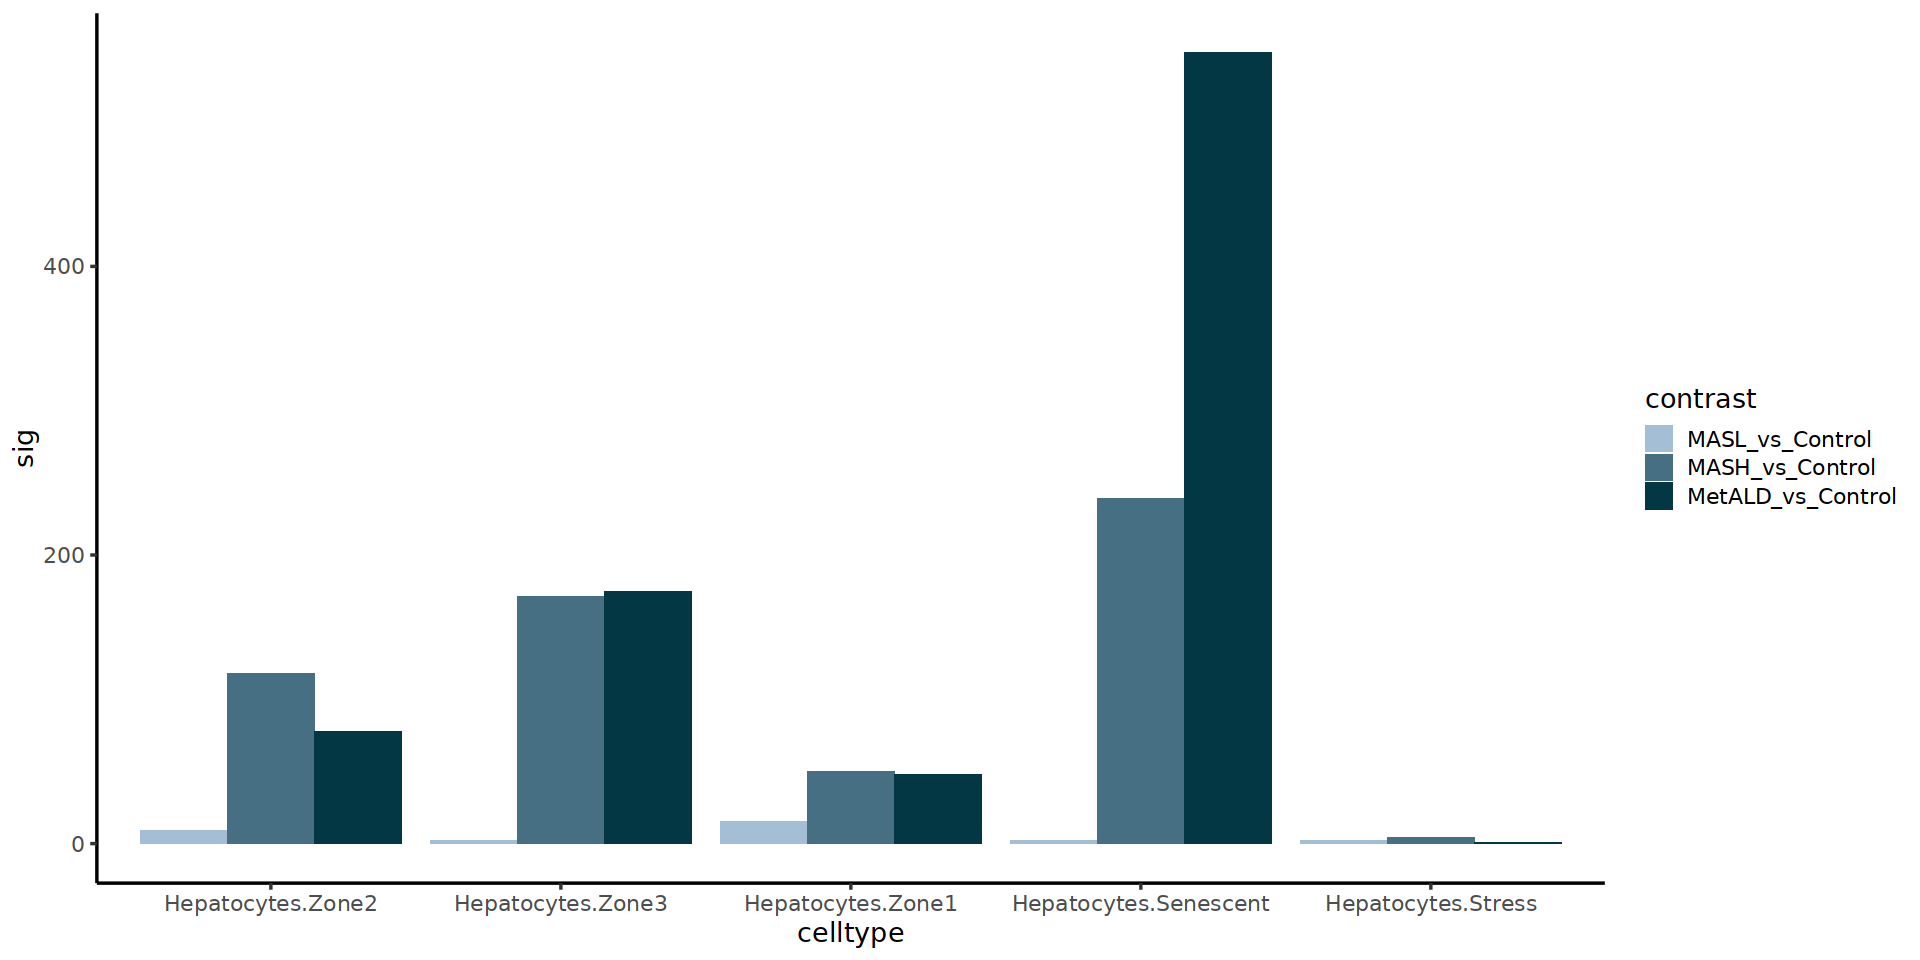

In [26]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### MASH_ALL

In [27]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Mast','Schwann')) {
        next
    }
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Filter for only samples with any counts in the cell type
    raw_counts = raw_counts[, (colSums(raw_counts != 0) > 0)]
    message("Donors detectected with celltype: ", ncol(raw_counts))
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    contrast.use <- 'MASH_ALL_vs_Control'
    
    condition.1 = c('MASH','MetALD')
    condition.2 = 'Control'
    message(" - ", contrast.use)

    # Create vectors of samples for each condition
    samples.condition.1 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.1) %>% 
                           pull(donor)
    samples.condition.2 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.2) %>% 
                           pull(donor)
    
    # Subset meta_cell for the current contrast
    meta_cell.use <- meta_cell %>% 
                 dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
    meta_cell.use[meta_cell.use$condition == 'MASH',]$condition <- 'MASH_ALL'
    meta_cell.use[meta_cell.use$condition == 'MetALD',]$condition <- 'MASH_ALL'
    rownames(meta_cell.use) <- meta_cell.use$donor
    
    # Subset raw_counts for the donors in meta_cell
    raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
    
    # Check if enough samples are present for both conditions
    if (length(unique(meta_cell$condition)) >= 2) {
        deseq.stats.tmp <- data.frame()
        
        # Light pre-filtering
        counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
        counts_filtered <- counts_filtered[,colSums(counts_filtered) > 0]

        # Run DESeq2
        dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                      colData = meta_cell.use, 
                                      design = deseq.formula)
        dds$condition <- relevel(dds$condition, ref = condition.2)
        dds <- DESeq(dds)
        dds.results <- results(dds)
        dds.results <- na.omit(dds.results[order(dds.results$padj), ])

        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
        
        # Collect summary statistics
        deseq.stats.tmp <- data.frame(
            celltype = cell.use,
            contrast = contrast.use,
            up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
            down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
            up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
            down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
            deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                       # Make Volcano plot - Padj
                        res = as.data.frame(dds.results)
                        res$SYMBOL = rownames(res)
                        res = res %>%
                        dplyr::filter(!is.na(SYMBOL)) %>%
                        dplyr::filter(padj < 0.1) %>%
                        dplyr::group_by(sign(log2FoldChange)) %>%
                        dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                        dplyr::top_n(50, rank) %>%
                        dplyr::mutate(delabel = SYMBOL) %>%
                        ungroup() %>%
                        dplyr::select(delabel, SYMBOL) %>%
                        right_join(res) %>%
                        dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                        # Add a new column for color based on significance and direction
                        res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                            ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                        # Get the number of upregulated and downregulated genes
                        n_up <- sum(res$changes == "Up-regulated")
                        n_down <- sum(res$changes == "Down-regulated")

                        # Modify log2FoldChange values to be max x
                        res$log2FoldChange[res$log2FoldChange > 10] <- 10
                        res$log2FoldChange[res$log2FoldChange < -10] <- -10
                        # Modify padj values to be max x 
                        res$padj[res$padj < 10^-200] <- 10^-200
                
                        plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                            theme_bw() +
                            labs(y="-log10(padj)", x="log2FoldChange", 
                               title=paste(cell.use, " - ",
                                           condition.1, "Vs", condition.2, "\n",
                                          "Up: ", n_up, "-",
                                           "Down: ", n_down)) +
                            geom_point() +
                            scale_color_manual(values=c("blue", "grey", "red")) + 
                            theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                            scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                        labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                            scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                        labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                            geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                          point.padding=0, min.segment.length=0,
                                          max.time=20, max.iter=1e5, box.padding=0.3)
                
                        ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                               height = 10, width = 10,
                               plot = plot, device = "pdf")
    } else {
        message("Not enough samples for contrast: ", contrast.use)
    }
}

[1] "Analyzing: Hepatocytes.Senescent"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 53 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Stress"


Donors detectected with celltype: 37

subsetting metadata accordingly - Check that value is equal to above: 37

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`


[1] "Analyzing: Hepatocytes.Zone1"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 72 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone2"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 52 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone3"


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 88 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [28]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Stress,MASL_vs_Control,141,115,2,0
Hepatocytes.Stress,MASH_vs_Control,86,190,2,4
Hepatocytes.Stress,MetALD_vs_Control,205,85,1,0
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26
Hepatocytes.Zone1,MetALD_vs_Control,426,613,48,23


In [29]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control
<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,3,316,768,1187
Hepatocytes.Stress,2,6,1,1
Hepatocytes.Zone1,17,76,71,170
Hepatocytes.Zone2,10,162,107,263
Hepatocytes.Zone3,2,216,240,476


In [33]:
deseq.stats2 <- deseq.stats

In [34]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control"))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

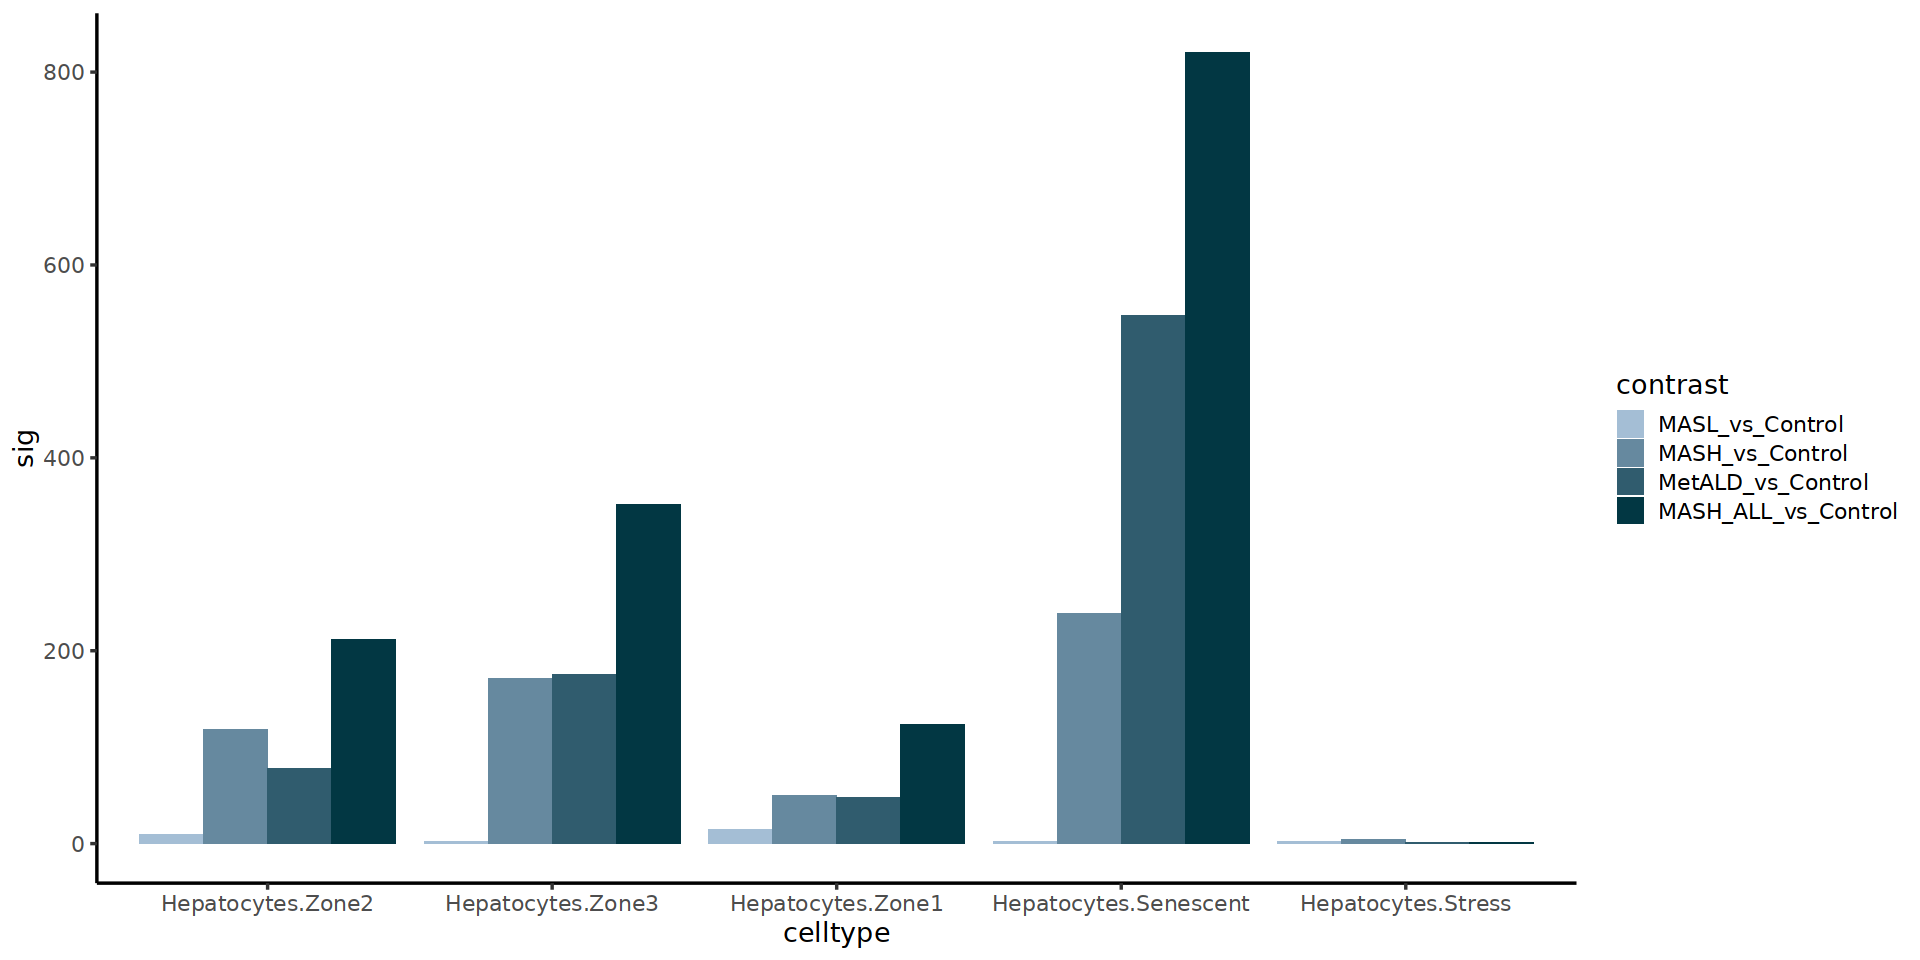

In [35]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### Fibrosis

In [36]:
contrasts  <- c('Fibrosis.stage')


# Define the DESeq2 formula
deseq.base.formula <- '~ Age.scaled + BMI.scaled + batch + Gender'

In [37]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Filter for only samples with any counts in the cell type
    raw_counts = raw_counts[, (colSums(raw_counts != 0) > 0)]
    message("Donors detected with cell type: ", ncol(raw_counts))
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 94 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Stress"


Donors detected with cell type: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

Joining with `by = join

[1] "Analyzing: Hepatocytes.Zone1"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 73 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone2"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 79 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone3"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 80 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [38]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Stress,MASL_vs_Control,141,115,2,0
Hepatocytes.Stress,MASH_vs_Control,86,190,2,4
Hepatocytes.Stress,MetALD_vs_Control,205,85,1,0
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26
Hepatocytes.Zone1,MetALD_vs_Control,426,613,48,23


In [39]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage
<chr>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,3,316,768,1187,3610
Hepatocytes.Stress,2,6,1,1,12
Hepatocytes.Zone1,17,76,71,170,1101
Hepatocytes.Zone2,10,162,107,263,1671
Hepatocytes.Zone3,2,216,240,476,2848


In [43]:
deseq.stats2 <- deseq.stats

In [44]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))

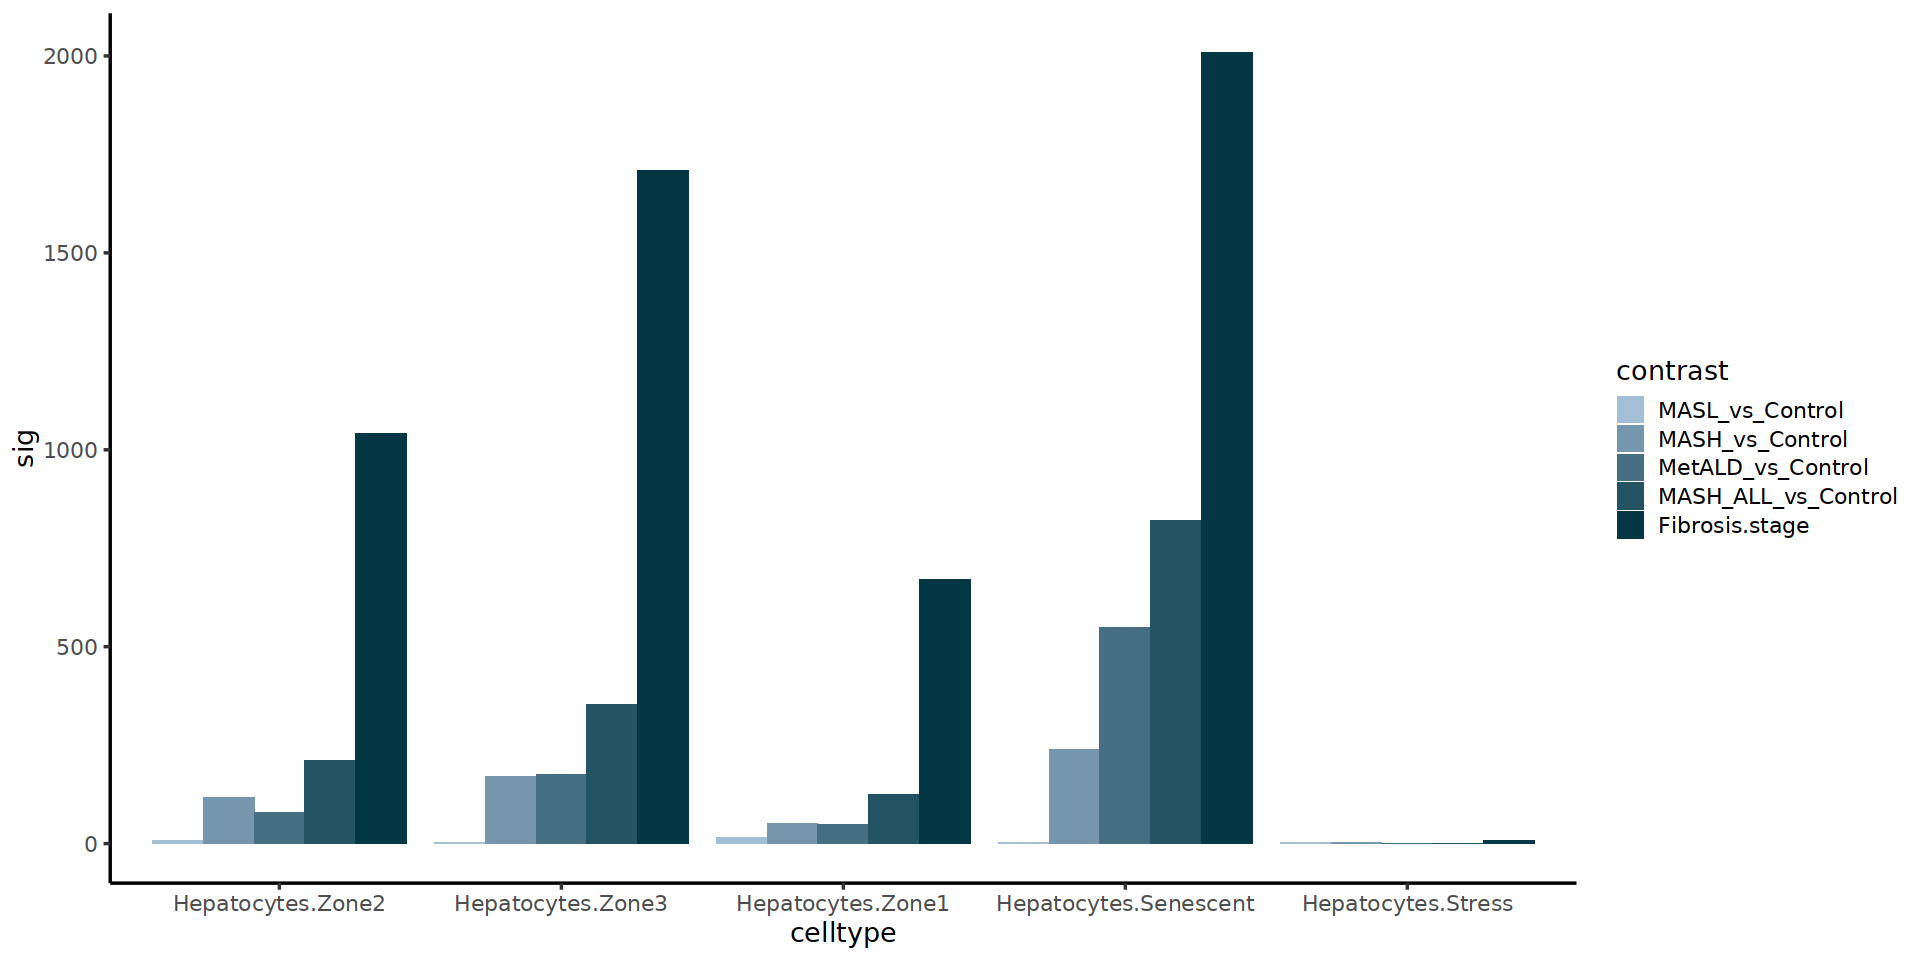

In [45]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [61]:
contrasts

[1] "Fibrosis.stage"

In [60]:
write.table(deseq.stats, paste0(outdir, '240918_MK_Hepatocytes_RNA_deseq_summary.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

### Other Meta

In [46]:
contrasts  <- c('Steatosis.grade', 'Lobular.inflammation', 'Ballooning', 'MASH.CRN.score..X.8')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + BMI.scaled + batch + Gender'

In [47]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Filter for only samples with any counts in the cell type
    raw_counts = raw_counts[, (colSums(raw_counts != 0) > 0)]
    message("Donors detected with cell type: ", ncol(raw_counts))
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

1 rows did not converge in beta, labelled in mcols(object)$betaConv. Use larger maxit argument with nbinomWaldTest

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 10 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
  -

[1] "Analyzing: Hepatocytes.Stress"


Donors detected with cell type: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

Joining with `by = joi

[1] "Analyzing: Hepatocytes.Zone1"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 14 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
  - Lobular.inflammation

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignor

[1] "Analyzing: Hepatocytes.Zone2"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

1 rows did not converge in beta, labelled in mcols(object)$betaConv. Use larger maxit argument with nbinomWaldTest

Joining with `by = join_by(SYMBOL)`
mean-dispersion relationship

final dispersion estimates

fitting model and testing

1 rows did not converge i

[1] "Analyzing: Hepatocytes.Zone3"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 23 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
  - Lobular.inflammation

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignor

In [48]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Stress,MASL_vs_Control,141,115,2,0
Hepatocytes.Stress,MASH_vs_Control,86,190,2,4
Hepatocytes.Stress,MetALD_vs_Control,205,85,1,0
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26
Hepatocytes.Zone1,MetALD_vs_Control,426,613,48,23


In [49]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,3,316,768,1187,3610,12,9,43,NA
Hepatocytes.Stress,2,6,1,1,12,0,0,1,1
Hepatocytes.Zone1,17,76,71,170,1101,15,4,26,NA
Hepatocytes.Zone2,10,162,107,263,1671,16,2,24,NA
Hepatocytes.Zone3,2,216,240,476,2848,43,11,90,NA


In [95]:
deseq.stats2 <- deseq.stats

In [96]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage','Steatosis.grade', 'Lobular.inflammation', 'Ballooning', 'MASH.CRN.score..X.8'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

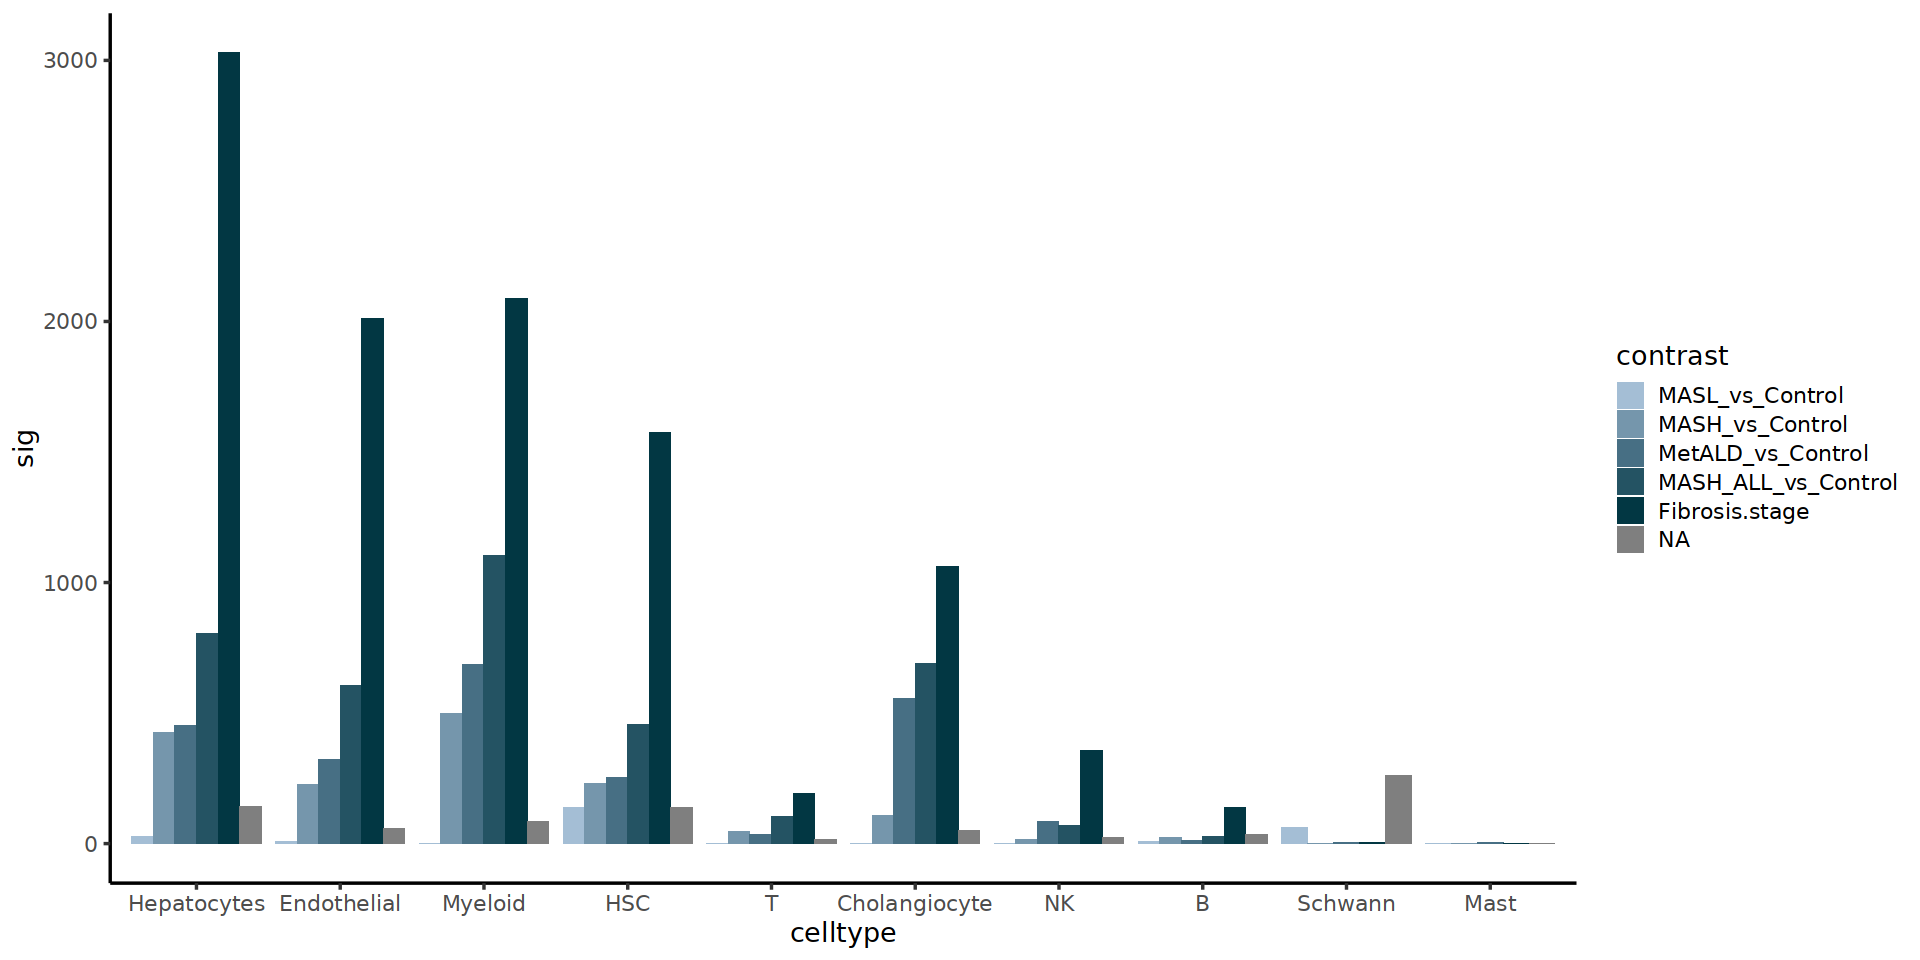

In [97]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [50]:
contrasts  <- c('Age','Age.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + BMI.scaled + batch + Gender'

In [51]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Filter for only samples with any counts in the cell type
    raw_counts = raw_counts[, (colSums(raw_counts != 0) > 0)]
    message("Donors detected with cell type: ", ncol(raw_counts))
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersi

[1] "Analyzing: Hepatocytes.Stress"


Donors detected with cell type: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersi

[1] "Analyzing: Hepatocytes.Zone1"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersi

[1] "Analyzing: Hepatocytes.Zone2"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersi

[1] "Analyzing: Hepatocytes.Zone3"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersi

In [52]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Stress,MASL_vs_Control,141,115,2,0
Hepatocytes.Stress,MASH_vs_Control,86,190,2,4
Hepatocytes.Stress,MetALD_vs_Control,205,85,1,0
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26
Hepatocytes.Zone1,MetALD_vs_Control,426,613,48,23


In [53]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,3,316,768,1187,3610,12,9,43,NA,10,11
Hepatocytes.Stress,2,6,1,1,12,0,0,1,1,0,0
Hepatocytes.Zone1,17,76,71,170,1101,15,4,26,NA,16,16
Hepatocytes.Zone2,10,162,107,263,1671,16,2,24,NA,63,64
Hepatocytes.Zone3,2,216,240,476,2848,43,11,90,NA,52,48


In [102]:
deseq.stats2 <- deseq.stats

In [103]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage','Steatosis.grade', 'Lobular.inflammation', 'Ballooning', 'MASH.CRN.score..X.8','Age','Age.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

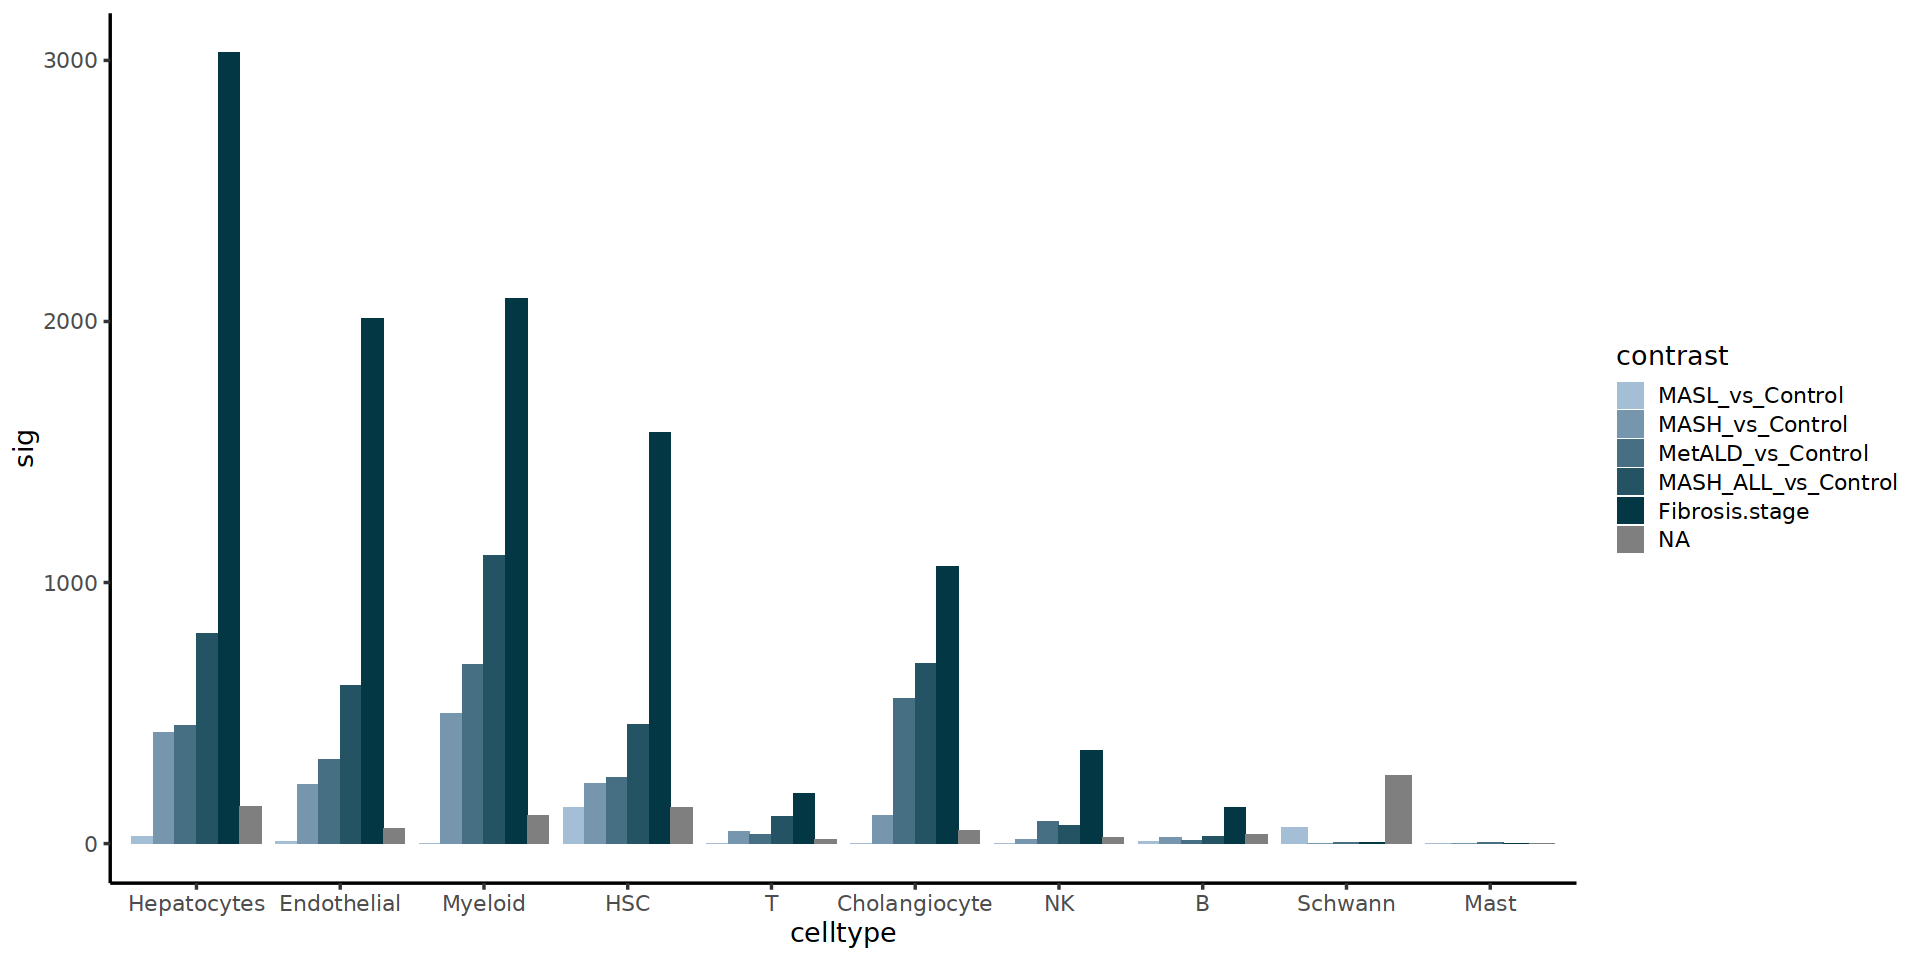

In [104]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [54]:
contrasts  <- c('BMI','BMI.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + batch + Gender'

In [55]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Filter for only samples with any counts in the cell type
    raw_counts = raw_counts[, (colSums(raw_counts != 0) > 0)]
    message("Donors detected with cell type: ", ncol(raw_counts))
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersi

[1] "Analyzing: Hepatocytes.Stress"


Donors detected with cell type: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersi

[1] "Analyzing: Hepatocytes.Zone1"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersi

[1] "Analyzing: Hepatocytes.Zone2"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersi

[1] "Analyzing: Hepatocytes.Zone3"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersi

In [56]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Stress,MASL_vs_Control,141,115,2,0
Hepatocytes.Stress,MASH_vs_Control,86,190,2,4
Hepatocytes.Stress,MetALD_vs_Control,205,85,1,0
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26
Hepatocytes.Zone1,MetALD_vs_Control,426,613,48,23


In [57]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,3,316,768,1187,3610,12,9,43,NA,10,11,14,16
Hepatocytes.Stress,2,6,1,1,12,0,0,1,1,0,0,0,0
Hepatocytes.Zone1,17,76,71,170,1101,15,4,26,NA,16,16,18,18
Hepatocytes.Zone2,10,162,107,263,1671,16,2,24,NA,63,64,43,45
Hepatocytes.Zone3,2,216,240,476,2848,43,11,90,NA,52,48,63,69


In [58]:
deseq.stats2 <- deseq.stats

In [59]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage','Steatosis.grade', 'Lobular.inflammation', 'Ballooning', 'MASH.CRN.score..X.8','Age','Age.scaled','BMI','BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

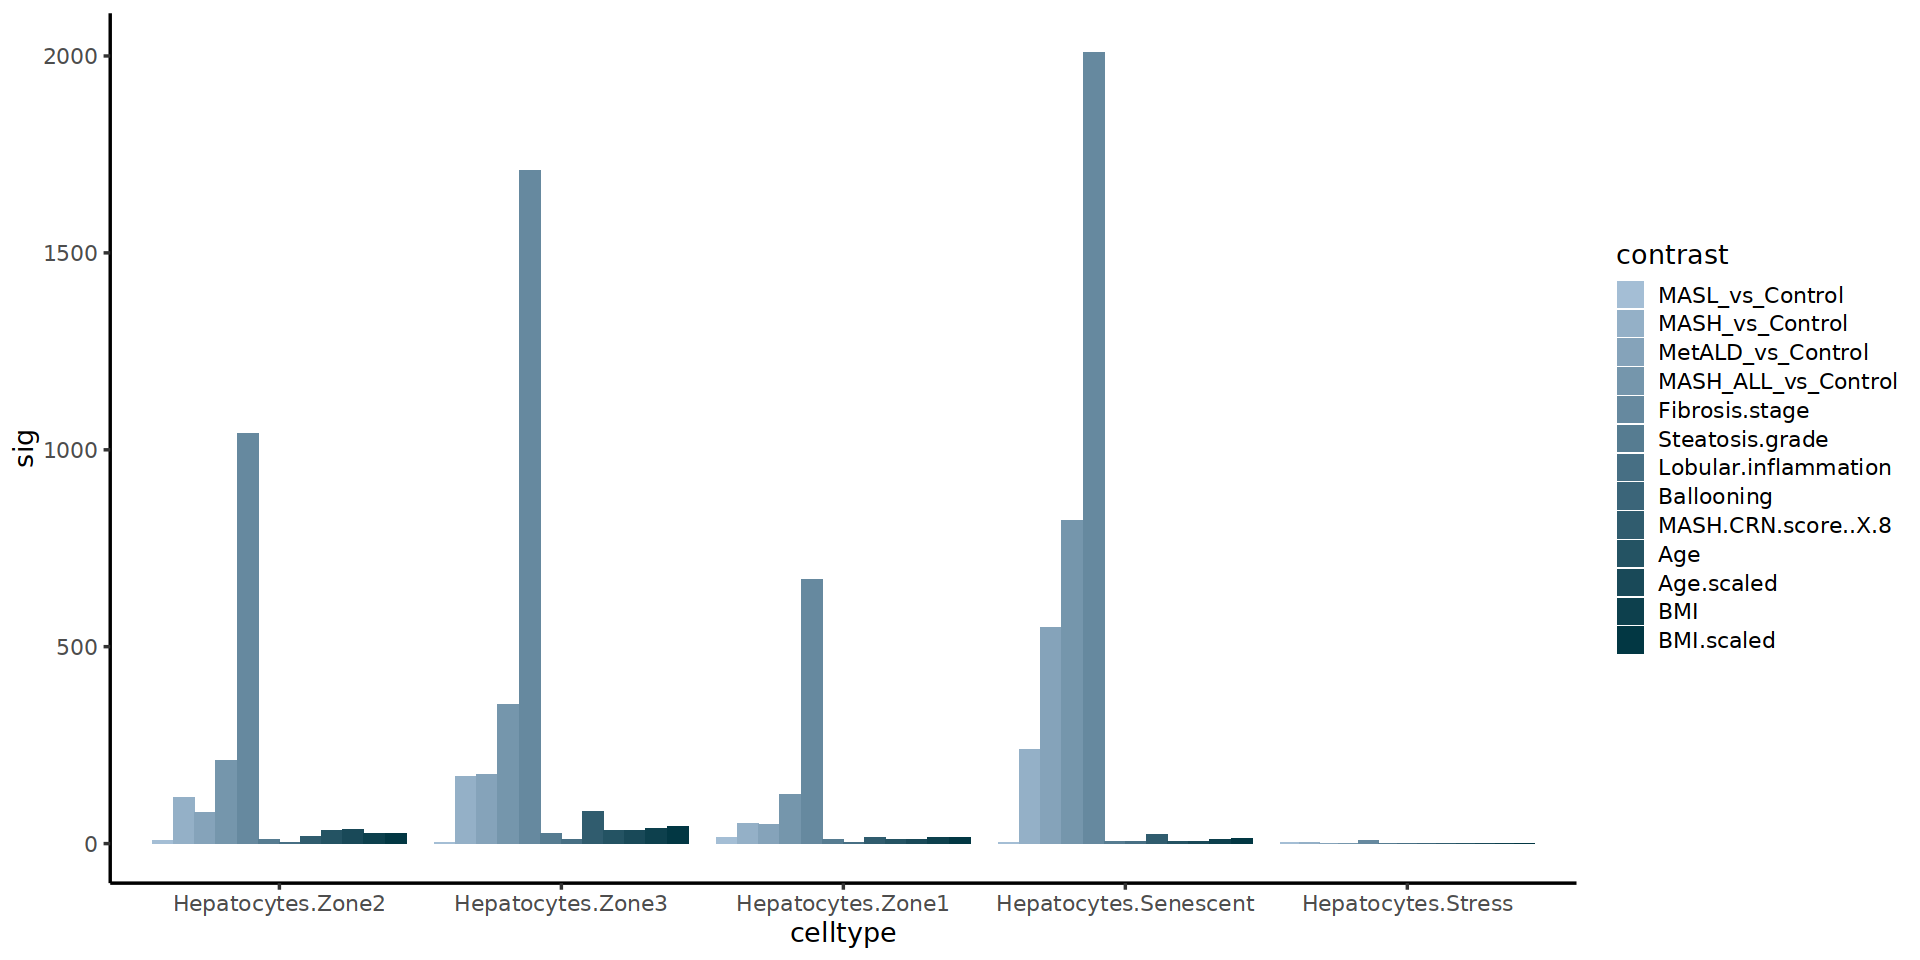

In [60]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [61]:
write.table(deseq.stats, paste0(outdir, '240918_MK_Hepatocytes_RNA_deseq_summary_add_contrasts.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

In [62]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Stress,MASL_vs_Control,141,115,2,0
Hepatocytes.Stress,MASH_vs_Control,86,190,2,4
Hepatocytes.Stress,MetALD_vs_Control,205,85,1,0
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26
Hepatocytes.Zone1,MetALD_vs_Control,426,613,48,23


In [37]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/mkim/Liver_Multiome/downstream/count.matrices/Hepatocytes_RNA/'
#Create outdir for results
outdir <- '/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/'
# dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_perdonor.RNA.counts.tsv')
#Cut off file suffices to get celltype names
cells <- gsub('_perdonor.RNA.counts.tsv','', files) 

In [38]:
meta = read.table("/nfs/lab/mkim/Liver_Multiome/downstream/01_DESEQ_RNA_Hepatocytes_Subtypes/RNA.meta.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,batch,disease_status,condition,Steatosis.grade,⋯,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,⋯,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,HL150001,392,1,541,5047,2779,thirdPR,Disease,MASL,1,⋯,0,0,0,0,1,M,47,27.1,-0.6385847,-0.01553551
2,HL150009,25,0,124,1655,513,fourthPR,Disease,MASL,1,⋯,0,0,0,0,1,M,37,29.4,-0.3346869,-0.75778750


[1] "donor_demux"           "Hepatocytes.Senescent" "Hepatocytes.Stress"   
 [4] "Hepatocytes.Zone1"     "Hepatocytes.Zone2"     "Hepatocytes.Zone3"    
 [7] "batch"                 "disease_status"        "condition"            
[10] "Steatosis.grade"       "Fibrosis.stage"        "Fat.distribution"     
[13] "Lobular.inflammation"  "Ballooning"            "Portal.inflammation"  
[16] "Hepatocyte.necrosis"   "MASH.CRN.score..X.8"   "Gender"               
[19] "Age"                   "BMI"                   "BMI.scaled"           
[22] "Age.scaled"

In [39]:
files

[1] "Hepatocytes.Senescent_perdonor.RNA.counts.tsv"
[2] "Hepatocytes.Stress_perdonor.RNA.counts.tsv"   
[3] "Hepatocytes.Zone1_perdonor.RNA.counts.tsv"    
[4] "Hepatocytes.Zone2_perdonor.RNA.counts.tsv"    
[5] "Hepatocytes.Zone3_perdonor.RNA.counts.tsv"

In [40]:
# List your contrasts  
conditions.1 = c("Low_Fibrosis", "High_Fibrosis") # disease
conditions.2 = c("Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [41]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Filter for only samples with any counts in the cell type
    raw_counts = raw_counts[, (colSums(raw_counts != 0) > 0)]
    message("Donors detected with cell type: ", ncol(raw_counts))
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        if (condition.1 == 'Low_Fibrosis') {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage <= 2) %>% 
                               pull(donor)
        } else {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage >= 3) %>% 
                               pull(donor)
        }
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        if(length(samples.condition.1) < 3) {
            next
        }
        if(length(samples.condition.2) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - High_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 45 unlabeled data points (too many overlaps). Consid

[1] "Analyzing: Hepatocytes.Stress"


Donors detected with cell type: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

3 rows did not converge in beta, labelled in mcols(object)$betaConv. Use larger maxit argument with nbinomWaldTest

Joining with `by = join_by(SYMBOL)`
  - High_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank)

[1] "Analyzing: Hepatocytes.Zone1"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - High_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 49 unlabeled data points (too many overlaps). Consid

[1] "Analyzing: Hepatocytes.Zone2"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - High_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 52 unlabeled data points (too many overlaps). Consid

[1] "Analyzing: Hepatocytes.Zone3"


Donors detected with cell type: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - High_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 81 unlabeled data points (too many overlaps). Consid

In [42]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,Low_Fibrosis_vs_Control,368,528,0,1
Hepatocytes.Senescent,High_Fibrosis_vs_Control,1633,1155,793,411
Hepatocytes.Stress,Low_Fibrosis_vs_Control,71,60,2,1
Hepatocytes.Stress,High_Fibrosis_vs_Control,75,73,7,4
Hepatocytes.Zone1,Low_Fibrosis_vs_Control,174,574,0,5
Hepatocytes.Zone1,High_Fibrosis_vs_Control,575,603,99,32
Hepatocytes.Zone2,Low_Fibrosis_vs_Control,218,634,1,2
Hepatocytes.Zone2,High_Fibrosis_vs_Control,889,676,173,40
Hepatocytes.Zone3,Low_Fibrosis_vs_Control,214,769,1,1


# FGSEA

In [4]:
#read in Ruth's preferred pathways
go <- gmtPathways('/nfs/lab/relgamal/MAGMA/c5.go.v2023.1.Hs.symbols.gmt')
kegg <- gmtPathways('/nfs/lab/relgamal/MAGMA/c2.cp.kegg.v2023.1.Hs.symbols.gmt')
reactome <- gmtPathways('/nfs/lab/relgamal/MAGMA/c2.cp.reactome.v2023.1.Hs.symbols.gmt')
pathways <- c(go, kegg, reactome)

go_mf <- gmtPathways('/nfs/lab/relgamal/MAGMA/c5.go.mf.v2023.1.Hs.symbols.gmt.txt')
go_bp <- gmtPathways('/nfs/lab/relgamal/MAGMA/c5.go.bp.v2023.1.Hs.symbols.gmt.txt')
pathways2 <- c(kegg,reactome,go_mf,go_bp)

#read in Hallmarks pathways (Jackie's preferred pathways)
hallmarks <- gmtPathways('/nfs/lab/relgamal/MAGMA/h.all.v2023.1.Hs.symbols.gmt.txt')

#make combined pathways list so can run all at once
all_pathways <- c(pathways2, hallmarks)

In [5]:
rps <- fread('/nfs/lab/tscc/ref/HGNC.ribosomal.genes.list.tsv', fill=TRUE, header=TRUE)
dim(rps)
head(rps)

[1] 247   7

HGNC ID (gene),Approved symbol,Approved name,Previous symbols,Aliases,Chromosome,Group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
HGNC:14275,MRPL1,mitochondrial ribosomal protein L1,,"BM022,uL1m",4q21.1,Large subunit mitochondrial ribosomal proteins
HGNC:14056,MRPL2,mitochondrial ribosomal protein L2,,"MRP-L14,RPML14,CGI-22,uL2m",6p21.1,Large subunit mitochondrial ribosomal proteins
HGNC:10379,MRPL3,mitochondrial ribosomal protein L3,RPML3,"MRL3,uL3m",3q22.1,Large subunit mitochondrial ribosomal proteins
HGNC:14276,MRPL4,mitochondrial ribosomal protein L4,,"CGI-28,uL4m",19p13.2,Large subunit mitochondrial ribosomal proteins
HGNC:14055,MRPL10,mitochondrial ribosomal protein L10,,"RPML8,MRP-L8,L10MT,MRP-L10,MRPL8,MGC17973,uL10m",17q21.32,Large subunit mitochondrial ribosomal proteins
HGNC:14042,MRPL11,mitochondrial ribosomal protein L11,,uL11m,11q13.2,Large subunit mitochondrial ribosomal proteins


In [6]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/'
#Create outdir for results
outdir.fgsea <- paste0(dir, 'fGSEA/')
 dir.create(outdir.fgsea)
#Get list of pseudobulk files
files <- list.files(dir, pattern='.dds.res')
files

Warning message in dir.create(outdir.fgsea):
“'/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/fGSEA' already exists”


[1] "Hepatocytes.Senescent_Age.dds.res"                     
 [2] "Hepatocytes.Senescent_Age.scaled.dds.res"              
 [3] "Hepatocytes.Senescent_BMI.dds.res"                     
 [4] "Hepatocytes.Senescent_BMI.scaled.dds.res"              
 [5] "Hepatocytes.Senescent_Fibrosis.stage.dds.res"          
 [6] "Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res"
 [7] "Hepatocytes.Senescent_Lobular.inflammation.dds.res"    
 [8] "Hepatocytes.Senescent_Low_Fibrosis_vs_Control.dds.res" 
 [9] "Hepatocytes.Senescent_MASH_ALL_vs_Control.dds.res"     
[10] "Hepatocytes.Senescent_MASH_vs_Control.dds.res"         
[11] "Hepatocytes.Senescent_MASH.CRN.score..X.8.dds.res"     
[12] "Hepatocytes.Senescent_MASL_vs_Control.dds.res"         
[13] "Hepatocytes.Senescent_MetALD_vs_Control.dds.res"       
[14] "Hepatocytes.Senescent_Steatosis.grade.dds.res"         
[15] "Hepatocytes.Stress_Age.dds.res"                        
[16] "Hepatocytes.Stress_Age.scaled.dds.res"                 
[17] "Hepatocytes.Stress_Ballooning.dds.res"                 
[18] "Hepatocytes.Stress_BMI.dds.res"                        
[19] "Hepatocytes.Stress_BMI.scaled.dds.res"                 
[20] "Hepatocytes.Stress_Fibrosis.stage.dds.res"             
[21] "Hepatocytes.Stress_High_Fibrosis_vs_Control.dds.res"   
[22] "Hepatocytes.Stress_Lobular.inflammation.dds.res"       
[23] "Hepatocytes.Stress_Low_Fibrosis_vs_Control.dds.res"    
[24] "Hepatocytes.Stress_MASH_ALL_vs_Control.dds.res"        
[25] "Hepatocytes.Stress_MASH_vs_Control.dds.res"            
[26] "Hepatocytes.Stress_MASH.CRN.score..X.8.dds.res"        
[27] "Hepatocytes.Stress_MASL_vs_Control.dds.res"            
[28] "Hepatocytes.Stress_MetALD_vs_Control.dds.res"          
[29] "Hepatocytes.Stress_Steatosis.grade.dds.res"            
[30] "Hepatocytes.Zone1_Age.dds.res"                         
[31] "Hepatocytes.Zone1_Age.scaled.dds.res"                  
[32] "Hepatocytes.Zone1_BMI.dds.res"                         
[33] "Hepatocytes.Zone1_BMI.scaled.dds.res"                  
[34] "Hepatocytes.Zone1_Fibrosis.stage.dds.res"              
[35] "Hepatocytes.Zone1_High_Fibrosis_vs_Control.dds.res"    
[36] "Hepatocytes.Zone1_Lobular.inflammation.dds.res"        
[37] "Hepatocytes.Zone1_Low_Fibrosis_vs_Control.dds.res"     
[38] "Hepatocytes.Zone1_MASH_ALL_vs_Control.dds.res"         
[39] "Hepatocytes.Zone1_MASH_vs_Control.dds.res"             
[40] "Hepatocytes.Zone1_MASH.CRN.score..X.8.dds.res"         
[41] "Hepatocytes.Zone1_MASL_vs_Control.dds.res"             
[42] "Hepatocytes.Zone1_MetALD_vs_Control.dds.res"           
[43] "Hepatocytes.Zone1_Steatosis.grade.dds.res"             
[44] "Hepatocytes.Zone2_Age.dds.res"                         
[45] "Hepatocytes.Zone2_Age.scaled.dds.res"                  
[46] "Hepatocytes.Zone2_BMI.dds.res"                         
[47] "Hepatocytes.Zone2_BMI.scaled.dds.res"                  
[48] "Hepatocytes.Zone2_Fibrosis.stage.dds.res"              
[49] "Hepatocytes.Zone2_High_Fibrosis_vs_Control.dds.res"    
[50] "Hepatocytes.Zone2_Lobular.inflammation.dds.res"        
[51] "Hepatocytes.Zone2_Low_Fibrosis_vs_Control.dds.res"     
[52] "Hepatocytes.Zone2_MASH_ALL_vs_Control.dds.res"         
[53] "Hepatocytes.Zone2_MASH_vs_Control.dds.res"             
[54] "Hepatocytes.Zone2_MASH.CRN.score..X.8.dds.res"         
[55] "Hepatocytes.Zone2_MASL_vs_Control.dds.res"             
[56] "Hepatocytes.Zone2_MetALD_vs_Control.dds.res"           
[57] "Hepatocytes.Zone2_Steatosis.grade.dds.res"             
[58] "Hepatocytes.Zone3_Age.dds.res"                         
[59] "Hepatocytes.Zone3_Age.scaled.dds.res"                  
[60] "Hepatocytes.Zone3_BMI.dds.res"                         
[61] "Hepatocytes.Zone3_BMI.scaled.dds.res"                  
[62] "Hepatocytes.Zone3_Fibrosis.stage.dds.res"              
[63] "Hepatocytes.Zone3_High_Fibrosis_vs_Control.dds.res"    
[64] "Hepatocytes.Zone3_Lobular.inflammation.dds.res"        
[65] "Hepatocytes.Zone3_Low_Fibro

In [7]:
outdir.fgsea

[1] "/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/fGSEA/"

In [ ]:
set.seed(999)
contrast.use = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 
                                    'BMI.scaled', 'Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control')
# setup
tresh = 0.05

for (i in seq_along(files)){
    # load table
    file.use = files[i]
    contrast.use <- str_remove(str_remove(file.use, "\\w*\\_"), '\\.dds\\.res')
    cell.use = str_split_fixed(file.use, paste0("_", contrast.use), n = 2)[,1]
    De.analysis = paste0(cell.use, "_", contrast.use)
    print(paste0("Analyzing: ", De.analysis))
    res = read.table(paste0(dir,file.use), sep = '\t')
    res <- res[!rownames(res) %in% rps$`Approved symbol`,]
    res <- res[!str_detect(rownames(res), '^MT-'),]

    # Formatting for FGSEA
    res$rank = res$stat
    res = data.frame("SYMBOL" = rownames(res),
                     "stat" = res$rank)
    res = res[!grepl(pattern = "NA", x = res$SYMBOL),]
    ranks <- deframe(res)
    ranks = sort(ranks, decreasing=TRUE)
    
    tryCatch({
    message("Running FGSEA")
    fgseaRes <- fgseaMultilevel(pathways=all_pathways, 
                                stats=ranks,
                                minSize  = 10, 
                                maxSize  = 500)
    message("Number of total enriched terms: ", nrow(fgseaRes))
    #fgseaRes.tresh = fgseaRes[fgseaRes$padj < tresh,]
    fgseaRes.tresh = fgseaRes
    message("Number of significant terms: ", sum(fgseaRes$padj < tresh))
    # Add categories
    #fgseaRes.tresh = merge(fgseaRes.tresh, gene.set.db, by = "pathway", ) 
    #fgseaRes.tresh = left_join(fgseaRes.tresh, gene.set.db, by = "pathway", multiple = 'first') ## THIS NEEDS TO BE FIXED, there are miultiple matches in gene.set.db
    message("Double check that it's the same number of terms: ", nrow(fgseaRes.tresh))
    # Subset for GO families of interest
    fgseaRes.tresh.use = fgseaRes.tresh
    message("Number of significant terms: ", nrow(fgseaRes.tresh.use))
    # Collapse terms 
    collapsedPathways <- collapsePathways(fgseaRes.tresh.use[order(pval)][padj < tresh], 
                                          all_pathways, ranks)
    mainPathways <- fgseaRes.tresh.use[pathway %in% collapsedPathways$mainPathways][
                             order(-NES), pathway]
    fgseaResMain <- fgseaRes.tresh.use[match(mainPathways, pathway)]
    # Save them
    file = paste(outdir.fgsea, "GSEA.CP_", De.analysis, ".go.kegg.reactome.hallmark.nothresh.res", sep = "")
    fwrite(fgseaRes.tresh.use, file = file, sep = "\t")
    # print plot
    plot = ggplot(fgseaResMain, aes(x = reorder(pathway, NES), y = NES)) +
      geom_col(aes(fill= NES>0)) +
      theme_bw()+
      labs(x="", y="Normalized Enrichment Score",
           title= paste(De.analysis,
                        " \n Gene Ontologies")) + 
        theme(axis.text=element_text(size=10), axis.title=element_text(size=16, face="bold"),
        axis.text.x=element_text(), plot.title=element_text(size=16, face="bold", hjust=0.5)) +
      coord_flip()
    ggsave(filename = paste(outdir.fgsea, "GSEA.CP_", De.analysis, ".go.kegg.reactome.hallmark.pdf", sep = ""),
                            height = 16, width = 20,
                            plot = plot, device = "pdf")
        }, error = function(e) {
    message("Error or no results found for ", De.analysis, ": ", e$message)
})
}

[1] "Analyzing: Hepatocytes.Senescent_Age.dds.res_Hepatocytes.Age"


Running FGSEA

Number of total enriched terms: 6382

Number of significant terms: 24

Double check that it's the same number of terms: 6382

Number of significant terms: 6382



[1] "Analyzing: Hepatocytes.Senescent_Age.scaled.dds.res_Hepatocytes.Age.scaled"


Running FGSEA

Number of total enriched terms: 6545

Number of significant terms: 16

Double check that it's the same number of terms: 6545

Number of significant terms: 6545



[1] "Analyzing: Hepatocytes.Senescent_BMI.dds.res_Hepatocytes.BMI"


...

Running FGSEA

Number of total enriched terms: 6169

Number of significant terms: 401

Double check that it's the same number of terms: 6169

Number of significant terms: 6169



[1] "Analyzing: Hepatocytes.Zone2_MASL_vs_Control.dds.res_Hepatocytes.Control"


Running FGSEA

Number of total enriched terms: 7536

Number of significant terms: 1917

Double check that it's the same number of terms: 7536

Number of significant terms: 7536



[1] "Analyzing: Hepatocytes.Zone2_MetALD_vs_Control.dds.res_Hepatocytes.Control"


Running FGSEA

Number of total enriched terms: 6978

Number of significant terms: 45

Double check that it's the same number of terms: 6978

Number of significant terms: 6978

